Markdown用法

<mark><font color=red size=4 face=雅黑>叠加字体的变化<font><mark>

<mark>黄色高亮<mark>

<font color=steel size=5 face=雅黑>5号雅黑</font>

***<font color=green>绿色+加粗+斜体</font>**

## 一、读取数据

In [1]:
import pandas as pd
import numpy as np
from tqdm import tqdm
import time
from datetime import datetime
# 导入plotly的graph_objects模块，这是用于创建交互式图表的库
# go是graph_objects的缩写，提供了各种图表类型如折线图、柱状图、散点图等
# 这个库可以创建高度交互式的可视化图表，支持缩放、悬停信息显示等功能
import plotly.graph_objects as go
import os

# 设置全局中文字体
# plt.rcParams['font.sans-serif'] = ['PingFang SC', 'SimHei', 'Microsoft YaHei', 'SimSun', 'Arial Unicode MS']
# plt.rcParams['axes.unicode_minus'] = False # 解决负号显示问题
# # 确保matplotlib能找到中文字体
# import matplotlib.font_manager as fm
# 打印可用字体列表，帮助调试
# print([f.name for f in fm.fontManager.ttflist])
#from pylab import mpl
# 设置显示中文字体
#mpl.rcParams["font.sans-serif"] = ["SimHei"]
# 设置正常显示符号


In [2]:
from WindPy import w
w.start()

Welcome to use Wind Quant API for Python (WindPy)!

COPYRIGHT (C) 2024 WIND INFORMATION CO., LTD. ALL RIGHTS RESERVED.
IN NO CIRCUMSTANCE SHALL WIND BE RESPONSIBLE FOR ANY DAMAGES OR LOSSES CAUSED BY USING WIND QUANT API FOR Python.


.ErrorCode=0
.Data=[OK!]

In [3]:
def get_stock_data(code, start_date, end_date):
    """
    从Wind获取股票数据
    
    参数:
    code: 股票代码
    start_date: 开始日期，格式'YYYY-MM-DD'
    end_date: 结束日期，格式'YYYY-MM-DD'
    
    返回:
    DataFrame: 包含股票数据的DataFrame
    """
    wind_data = w.wsd(code, "close,open,high,low,volume,pct_chg", start_date, end_date, "PriceAdj=F")
    
    if wind_data.ErrorCode != 0:
        print(f"获取数据出错: {wind_data.Data}")
        return None
        
    # 转换为DataFrame
    df = pd.DataFrame(data=wind_data.Data, 
                     index=wind_data.Fields, 
                     columns=wind_data.Times).T
    
    # 重命名列以匹配yfinance格式
    df.columns = ['Close', 'Open', 'High', 'Low', 'Volume', 'Change']
    df.index.name = 'Date'
    
    print(f"成功获取{code}的数据，共{len(df)}条记录")
    return df


data_raw = get_stock_data("000001.SH", "1995-01-01", "2025-02-28")

data = data_raw.copy()
data

成功获取000001.SH的数据，共7320条记录


,Close,Open,High,Low,Volume,Change
Date,,,,,,
1995-01-03,639.8800,637.7200,647.7100,630.5300,2.345180e+07,-1.233272
1995-01-04,653.8100,641.9000,655.5100,638.8600,4.222200e+07,2.176971
1995-01-05,646.8900,656.2000,657.4500,645.8100,4.301230e+07,-1.058411
1995-01-06,640.7600,642.7500,643.8900,636.3300,4.874820e+07,-0.947611
1995-01-09,625.9700,637.5200,637.5500,625.0400,5.098510e+07,-2.308197
...,...,...,...,...,...,...
2025-02-24,3373.0276,3374.0813,3384.8106,3355.8694,5.981882e+10,-0.180083
2025-02-25,3346.0398,3345.6534,3369.5583,3337.8448,5.275786e+10,-0.800106
2025-02-26,3380.2144,3351.2093,3380.2144,3351.2093,5.539920e+10,1.021345


In [4]:
# 将数据保存到Excel文件
# data.to_excel('000001.xlsx')
# print(f"数据已保存至: 000001.xlsx")



## 二、识别拐点

In [4]:

'''====================1.Rolling Window 算法==========================='''
# 检测局部顶部的函数
# data: 价格数据数组
# curr_index: 当前检查的索引位置
# order: 窗口大小的一半（窗口总大小 = 2*order + 1）
# 这个函数确实是在检查 k 点（即 curr_index - order）是否是局部最大值点。函数的逻辑是：
# 计算窗口中心点 k = curr_index - order
# 获取中心点的价格值 v = data[k]
# 检查中心点前后各 order 个点的价格
# 如果窗口内有任何一个点的价格高于中心点，则 k 点不是顶部
# 只有当 k 点的价格高于或等于窗口内所有其他点时，才认为它是局部顶部（最大值点）
# 这是一个典型的滚动窗口方法来识别价格数据中的局部极值点。
def rw_top(data: np.array, curr_index: int, order: int) -> bool:
    # 确保只处理价格数据
    if data.ndim > 1:
        price_data = data[:, 0]  # 使用第一列作为价格
    else:
        price_data = data
        
    if curr_index < order * 2 + 1:
        return False

    top = True
    k = curr_index - order
    v = price_data[k]
    
    for i in range(1, order + 1):
        if price_data[k + i] > v or price_data[k - i] > v:
            top = False
            break
    
    return top

# 检测局部底部的函数
# data: 价格数据数组
# curr_index: 当前检查的索引位置
# order: 窗口大小的一半（窗口总大小 = 2*order + 1）
def rw_bottom(data: np.array, curr_index: int, order: int) -> bool:
    # 确保只处理价格数据
    if data.ndim > 1:
        price_data = data[:, 0]  # 使用第一列作为价格
    else:
        price_data = data
        
    if curr_index < order * 2 + 1:
        return False

    bottom = True
    k = curr_index - order
    v = price_data[k]
    
    for i in range(1, order + 1):
        if price_data[k + i] < v or price_data[k - i] < v:
            bottom = False
            break
    
    return bottom

# 找出所有极值点的函数
# data: 价格数据数组
# order: 窗口大小的一半
def rw_extremes(data: np.array, order:int):
    # 初始化存储顶部和底部的列表
    tops = []
    bottoms = []
    
    # 遍历整个数据集，i的取值范围是从0到data数组长度减1。根据上下文可以看到，data是一个包含7320行的价格数据数组，所以i的取值范围是0到7319。
    for i in range(len(data)):
        # 检查是否是顶部
        if rw_top(data, i, order):
            # 记录顶部信息：
            # top[0] = 确认索引（当前索引i）
            # top[1] = 顶部索引（i - order，即窗口中心）
            # top[2] = 顶部价格
            # 创建一个包含顶部信息的列表:
            # i: 当前确认索引位置
            # i - order: 顶部实际位置(窗口中心)
            # data[i - order]: 顶部价格值
            top = [i, i - order, data[i - order]]
            tops.append(top)  # 将找到的顶部点信息添加到tops列表中
        
        # 检查是否是底部
        if rw_bottom(data, i, order):
            # 记录底部信息：
            # bottom[0] = 确认索引（当前索引i）
            # bottom[1] = 底部索引（i - order，即窗口中心）
            # bottom[2] = 底部价格
            bottom = [i, i - order, data[i - order]]
            bottoms.append(bottom)
    
    return tops, bottoms

    


'''====================3.Perceptually Important Points 算法==========================='''

def find_pips(data: np.array, n_pips: int, dist_measure: int):
    """
    感知重要点(Perceptually Important Points, PIP)算法
    
    参数:
    data: 价格数据数组
    n_pips: 要识别的重要点数量
    dist_measure: 距离度量方式
        1 = 欧几里得距离(Euclidean Distance)
        2 = 垂直距离(Perpendicular Distance)
        3 = 垂直距离(Vertical Distance)
    
    返回:
    pips_x: 重要点的索引
    pips_y: 重要点的价格值
    """
    # 初始化，将起点和终点作为第一批重要点
    # len(data)-1 是因为数组索引从0开始,最后一个元素的索引是长度减1
    pips_x = [0, len(data) - 1]  # 索引,0表示第一个点,len(data)-1表示最后一个点
    pips_y = [data[0], data[-1]]  # 价格,data[0]是第一个价格,data[-1]是最后一个价格

    # 迭代添加n_pips-2个重要点（因为已经有起点和终点两个点）
    for curr_point in range(2, n_pips):
        md = 0.0  # 最大距离
        md_i = -1  # 最大距离对应的索引,初始化为-1表示还未找到最大距离点
        insert_index = -1  # 插入位置,初始化为-1表示还未确定插入位置

        # 遍历当前已有的重要点之间的所有区间
        for k in range(0, curr_point - 1):
            # 获取左右相邻重要点的索引
            # 获取相邻两个重要点的索引,用于构建线段
            # left_adj表示左侧重要点在pips数组中的位置
            # right_adj表示右侧重要点在pips数组中的位置
            left_adj = k  
            right_adj = k + 1

            # 计算这两个重要点之间的直线方程 y = slope * x + intercept
            # 用于后续计算其他点到这条线段的距离
            time_diff = pips_x[right_adj] - pips_x[left_adj]
            price_diff = pips_y[right_adj] - pips_y[left_adj]
            slope = price_diff / time_diff  # 计算斜率
            intercept = pips_y[left_adj] - pips_x[left_adj] * slope  # 计算截距

            # 遍历两个重要点之间的所有点
            for i in range(pips_x[left_adj] + 1, pips_x[right_adj]):
                d = 0.0  # 距离
                
                # 根据选择的距离度量方式计算距离
                if dist_measure == 1:  # 欧几里得距离
                    # 计算点到左右两个重要点的欧几里得距离之和
                    d = ((pips_x[left_adj] - i) ** 2 + (pips_y[left_adj] - data[i]) ** 2) ** 0.5
                    d += ((pips_x[right_adj] - i) ** 2 + (pips_y[right_adj] - data[i]) ** 2) ** 0.5
                elif dist_measure == 2:  # 垂直距离（点到直线的垂直距离）
                    # 计算点到直线的垂直距离
                    d = abs((slope * i + intercept) - data[i]) / (slope ** 2 + 1) ** 0.5
                else:  # 垂直距离（点到直线的垂直距离，不考虑斜率）
                    # 计算点到直线的垂直距离（简化版）
                    d = abs((slope * i + intercept) - data[i])

                # 如果找到更大的距离，更新最大距离和对应的索引
                if d > md:
                    md = d
                    # 记录当前找到的最大距离点的索引i
                    md_i = i
                    # right_adj是当前区间右端点的位置,将新点插入到right_adj位置
                    insert_index = right_adj

        # 将新找到的重要点插入到重要点列表中
        pips_x.insert(insert_index, md_i)
        pips_y.insert(insert_index, data[md_i])

    return pips_x, pips_y

In [5]:
import pandas as pd  # 用于数据处理和分析
import numpy as np   # 用于数值计算
import matplotlib.pyplot as plt  # 用于数据可视化
import mplfinance as mpf  # 用于绘制金融图表
from matplotlib import style
from dataclasses import dataclass

# 设置matplotlib显示中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'SimSun', 'KaiTi', 'FangSong', 
                                  'Source Han Sans CN', 'Source Han Serif CN', 'WenQuanYi Micro Hei']
plt.rcParams['axes.unicode_minus'] = False  # 正确显示负号


# 这是Python的一个装饰器,用来简化类的定义。它会自动帮我们生成__init__()等基础方法,让我们只需要定义类的属性就可以了,不用写很多重复的代码。
#__init__()是类的构造函数,当我们创建类的实例时会自动调用它来初始化实例的属性。比如定义一个普通的类需要写构造函数,而用@dataclass就不用写了。
@dataclass  
class FlagPattern:  # 定义一个旗形模式类,用于存储和表示股票价格中的旗形形态特征
    """
    这是一个使用Python的dataclass装饰器定义的类，用于表示旗形和三角旗形态。
    @dataclass是Python的一个装饰器，它会自动为类生成特殊方法，如__init__、__repr__等，
    简化了数据类的创建过程，使代码更加简洁。
    """

    # 旗形和三角旗形态的数据结构
    
    # 属性:
    base_x: int         # 趋势起点索引，旗杆的底部
    base_y: float       # 趋势起点价格
    
    tip_x: int   = -1       # 旗杆顶部/底部索引，旗帜开始点。初始化为-1表示尚未找到有效的旗杆顶部/底部点
    tip_y: float = -1.      # 旗杆顶部/底部价格。初始化为-1表示尚未找到有效的价格点
    
    conf_x: int   = -1      # 形态确认点索引（突破点）
    conf_y: float = -1.     # 形态确认点价格
    
    pennant: bool = False   # True表示三角旗，False表示旗形
    
    flag_width: int    = -1    # 旗帜宽度（时间跨度）
    flag_height: float = -1.   # 旗帜高度（价格跨度）
    
    pole_width: int    = -1    # 旗杆宽度（时间跨度）
    pole_height: float = -1.   # 旗杆高度（价格跨度）
    
    # 旗帜的上下趋势线，截距在旗杆顶部/底部
    support_intercept: float = -1.  # 支撑线截距
    support_slope: float = -1.      # 支撑线斜率
    resist_intercept: float = -1.   # 阻力线截距
    resist_slope: float = -1.       # 阻力线斜率

    # 新增成交量相关属性
    avg_flag_volume: float = -1.  # 旗帜区间的平均成交量
    breakout_volume: float = -1.  # 突破时的成交量
    volume_ratio: float = -1.     # 突破成交量/平均成交量的比率


def check_bear_pattern_pips(pending: FlagPattern, data: np.array, i: int, order: int, volume: np.array = None):
    """
    检查熊市旗形/三角旗形态（基于PIP点方法）
    
    参数:
    pending: FlagPattern - 待填充的旗形对象
    data: np.array - 价格数据数组
    i: int - 当前检查的索引位置
    order: int - 滚动窗口大小参数
    
    返回:
    bool - 如果识别到有效形态则返回True，否则返回False
    """

    # 找出自局部顶部以来的最低价格（旗杆底部）
    # 从旗杆底部(pending.base_x)到当前检查位置(i)的数据切片
    # data[pending.base_x: i + 1]表示取数据从旗杆底部到当前位置的子集
    # i+1是因为在Python中切片的右边界是开区间,即不包含i+1这个位置
    
    # pending.base_x是旗杆底部的索引位置
    # 这行代码从旗杆底部(pending.base_x)到当前检查位置(i)提取了一段数据
    # i+1是因为切片右边界是开区间,所以需要+1才能包含i这个位置
    data_slice = data[pending.base_x: i + 1]  
    
    # 切片(slice)是从数组中提取一段连续数据的操作
    # 例如data_slice = data[pending.base_x: i + 1]就是一个切片操作
    # 它从原始数组data中提取了从pending.base_x到i的这一段数据
    # argmin()返回切片中最小值的索引位置
    # 由于切片是原始数组的一部分,所以需要加上切片起点pending.base_x才是在原始数组中的实际位置
    min_i = data_slice.argmin() + pending.base_x  # 自局部顶部以来的最低点索引
    
    # 确保从最低点到当前位置有足够的距离来形成旗帜
    if i - min_i < max(5, order * 0.5):  # 这行代码检查当前位置i到最低点min_i的距离是否小于两个值中的较大值:
                                         # 1. 固定值5
                                         # 2. order参数的一半
                                         # 如果距离太小,说明还没有形成足够宽的旗形形态,返回False
        return False
    
    # 测试旗帜宽度/高度
    pole_width = min_i - pending.base_x  # 旗杆宽度
    flag_width = i - min_i  # 旗帜宽度
    # 旗帜宽度应小于旗杆宽度的一半
    if flag_width > pole_width * 0.5:
        return False

    pole_height = pending.base_y - data[min_i]  # 旗杆高度
    flag_height = data[min_i:i+1].max() - data[min_i]  # 旗帜高度
    # 旗帜高度应小于旗杆高度的一半
    if flag_height > pole_height * 0.5:
        return False

    # 到这里，宽度/高度检查通过
    
    # 找出旗帜部分的感知重要点(PIP)
    # 找出从最低点到当前索引之间的5个PIP点
    # 5表示要找出5个重要点位(PIP点)

    pips_x, pips_y = find_pips(data[min_i:i+1], 5, 3)

    # 检查中心PIP点是否低于相邻的两个点，形成/\/\形状
    if not (pips_y[2] < pips_y[1] and pips_y[2] < pips_y[3]):
        return False
    
    # 计算旗帜的支撑线和阻力线
    # 支撑线：连接第1个和第3个PIP点
    support_rise = pips_y[2] - pips_y[0]  # 支撑线上升高度
    support_run = pips_x[2] - pips_x[0]  # 支撑线水平距离
    support_slope = support_rise / support_run  # 支撑线斜率
    support_intercept = pips_y[0]  # 支撑线截距
    
    # 阻力线：连接第2个和第4个PIP点
    resist_rise = pips_y[3] - pips_y[1]  # 阻力线上升高度
    resist_run = pips_x[3] - pips_x[1]  # 阻力线水平距离
    resist_slope = resist_rise / resist_run  # 阻力线斜率
    resist_intercept = pips_y[1] + (pips_x[0] - pips_x[1]) * resist_slope  # 阻力线截距

    # 计算两条线的交点
    if resist_slope != support_slope:  # 非平行线
        intersection = (support_intercept - resist_intercept) / (resist_slope - support_slope)
    else:
        intersection = -flag_width * 100  # 平行线，设置一个远离旗帜区域的交点

    # # 如果交点在旗帜区域内，则不是有效的旗形/三角旗
    if intersection <= pips_x[4] and intersection >= 0:
        return False
    


    # 检查当前点是否突破旗帜下边界（支撑线），确认形态
    support_endpoint = pips_y[0] + support_slope * pips_x[4]
    if pips_y[4] > support_endpoint:  # 如果价格高于支撑线，则未突破
        return False
    
    flag_start = min_i  # 旗帜开始点
    flag_volumes = volume[flag_start:i+1]
    avg_flag_volume = np.mean(flag_volumes)
    
    # # 确认点的成交量应大于旗帜区域的平均成交量
    if volume[i] < avg_flag_volume:
        return False  # 成交量不足，不确认突破
    
        # 放宽成交量确认条件，不要求突破成交量一定大于平均成交量
    # recent_avg_volume = np.mean(flag_volumes[-3:]) if len(flag_volumes) >= 3 else avg_flag_volume

    # 成交量可以低于平均，但必须高于最近几个交易日的平均并有增长趋势
    # if volume[i] < recent_avg_volume :
    #     return False  # 成交量太小，不确认突破
    
    # 判断是旗形还是三角旗
    # 如果阻力线向下倾斜（斜率为负），则为三角旗
    if resist_slope < 0:
        pending.pennant = True
    else:
        pending.pennant = False
    
    # 过滤严重发散的线（交点太近）
    if intersection < 0 and intersection > -flag_width:
        return False

    # 形态确认，填充旗形对象的属性
    pending.tip_x = min_i  # 旗杆底部索引
    pending.tip_y = data[min_i]  # 旗杆底部价格
    pending.conf_x = i  # 确认点索引
    pending.conf_y = data[i]  # 确认点价格
    # 保存成交量信息到旗形对象
    pending.avg_flag_volume = avg_flag_volume
    pending.breakout_volume = float(volume[i])
    pending.volume_ratio = float(volume[i]) / avg_flag_volume
    pending.flag_width = flag_width  # 旗帜宽度
    pending.flag_height = flag_height  # 旗帜高度
    pending.pole_width = pole_width  # 旗杆宽度
    pending.pole_height = pole_height  # 旗杆高度
    pending.support_slope = support_slope  # 支撑线斜率
    pending.support_intercept = support_intercept  # 支撑线截距
    pending.resist_slope = resist_slope  # 阻力线斜率
    pending.resist_intercept = resist_intercept  # 阻力线截距
    
    return True  # 返回True表示识别到有效形态
    

def check_bull_pattern_pips(pending: FlagPattern, data: np.array, i:int, order:int, volume: np.array = None):
    """
    检查牛市旗形/三角旗形态（基于PIP点方法），可选结合成交量确认
    
    参数:
    pending: FlagPattern - 待填充的旗形对象
    data: np.array - 价格数据数组(一维)
    i: int - 当前检查的索引位置
    order: int - 滚动窗口大小参数
    volume_data: np.array - 可选的成交量数据数组(一维)
    
    返回:
    bool - 如果识别到有效形态则返回True，否则返回False
    """

    # 找出自局部底部以来的最高价格（旗杆顶部）
    # 这行代码从价格数组data中提取了从pending.base_x（局部底部）到i+1（当前位置）的一段数据。i+1是为了包含当前价格点，因为Python切片是左闭右开的。
    data_slice = data[pending.base_x: i + 1]  # i + 1包含当前价格

    # 这行代码在寻找从局部底部到当前位置之间的最高价格点的索引。
    # data_slice.argmax()找到切片中最高价格的位置，加上pending.base_x是为了将这个相对位置转换为在原始数组中的绝对位置。这个索引将用于确定旗杆的顶部位置。
    max_i = data_slice.argmax() + pending.base_x  # 自局部底部以来的最高点索引
    pole_width = max_i - pending.base_x  # 旗杆宽度
    
    # 确保从最高点到当前位置有足够的距离来形成旗帜
    if i - max_i < max(5, order * 0.5):
        return False

    # 测试旗帜宽度/高度
    flag_width = i - max_i  # 旗帜宽度
    # 旗帜宽度应小于旗杆宽度的一半
    if flag_width > pole_width * 0.5:
        return False

    pole_height = data[max_i] - pending.base_y  # 旗杆高度
    flag_height = data[max_i] - data[max_i:i+1].min()  # 旗帜高度
    # 旗帜高度应小于旗杆高度的一半
    if flag_height > pole_height * 0.5:
        return False

    # 找出旗帜部分的感知重要点(PIP)
    # 找出从最高点到当前索引之间的5个PIP点
    # pips_y[0]是第一个PIP点的价格,代表旗帜区域的起始点
    # pips_y[4]是最后一个PIP点的价格,代表当前价格点
    pips_x, pips_y = find_pips(data[max_i:i+1], 5, 3)  

    # 检查中心PIP点是否高于相邻的两个点，形成\/\/形状
    if not (pips_y[2] > pips_y[1] and pips_y[2] > pips_y[3]):
        return False
        
    # 计算旗帜的阻力线和支撑线
    # 阻力线：连接第1个和第3个PIP点
    # 计算阻力线的上升高度，即第3个PIP点(pips_y[2])与第1个PIP点(pips_y[0])的垂直距离
    resist_rise = pips_y[2] - pips_y[0]  # 阻力线上升高度
    
    # 计算阻力线的水平距离，即第3个PIP点(pips_x[2])与第1个PIP点(pips_x[0])的水平距离
    resist_run = pips_x[2] - pips_x[0]  # 阻力线水平距离
    
    # 计算阻力线的斜率，使用上升高度除以水平距离
    # 斜率为正表示向上倾斜，为负表示向下倾斜
    resist_slope = resist_rise / resist_run  # 阻力线斜率
    
    # 计算阻力线的截距，即阻力线与y轴的交点
    # 这里直接使用第1个PIP点的y值作为截距
    resist_intercept = pips_y[0]  # 阻力线截距

    # 支撑线：连接第2个和第4个PIP点
    support_rise = pips_y[3] - pips_y[1]  # 支撑线上升高度
    support_run = pips_x[3] - pips_x[1]  # 支撑线水平距离
    support_slope = support_rise / support_run  # 支撑线斜率
    support_intercept = pips_y[1] + (pips_x[0] - pips_x[1]) * support_slope  # 支撑线截距

    # 计算两条线的交点
    if resist_slope != support_slope:  # 非平行线
        # 计算支撑线和阻力线的交点的x坐标
        # 使用两条直线方程联立求解:
        # y = resist_slope * x + resist_intercept
        # y = support_slope * x + support_intercept
        # 解出x坐标(intersection)
        intersection = (support_intercept - resist_intercept) / (resist_slope - support_slope)
    else:
        # 当支撑线和阻力线平行时,将交点设置在旗帜区域左侧很远的位置
        # 这样做是为了确保交点不会落在旗帜区域内
        # flag_width是旗帜的宽度,乘以100是为了将交点设得足够远
        intersection = -flag_width * 100  # 平行线，设置一个远离旗帜区域的交点

    # 如果交点在旗帜区域内，则不是有效的旗形/三角旗
    # 因为有效的旗形/三角旗的支撑线和阻力线应该在旗帜区域外相交
    # 如果在旗帜区域内相交，说明两条趋势线收敛太快，形成的是一个楔形形态而不是旗形
    # 楔形形态通常代表趋势的延续或反转，而旗形则代表趋势的暂时休整
    if intersection <= pips_x[4] and intersection >= 0:
        return False
    


    
    # 过滤严重发散的线（交点太近）
    # 如果交点在旗帜宽度的负1倍范围内,说明两条趋势线发散得太快,不是有效形态
    # 例如:如果旗帜宽度为10,那么交点应该在x<-10的位置,否则说明趋势线发散太快
    if intersection < 0 and intersection > -1.0 * flag_width:
        return False

    # 检查当前点是否突破旗帜上边界（阻力线），确认形态
    resist_endpoint = pips_y[0] + resist_slope * pips_x[4]
    if pips_y[4] < resist_endpoint:  # 如果价格低于阻力线，则未突破
        return False
    
    flag_start = max_i  # 旗帜开始点
    flag_volumes = volume[flag_start:i+1]
    avg_flag_volume = np.mean(flag_volumes)
    
    
    # 确认点的成交量应大于旗帜区域的平均成交量
    # if volume[i] <= avg_flag_volume:
    #     return False  # 成交量不足，不确认突破
    

    # # 放宽成交量确认条件，不要求突破成交量一定大于平均成交量
    # recent_avg_volume = np.mean(flag_volumes[-3:]) if len(flag_volumes) >= 3 else avg_flag_volume

    # # 成交量可以低于平均，但必须高于最近几个交易日的平均并有增长趋势
    # if volume[i] < recent_avg_volume :
    #     return False  # 成交量太小，不确认突破


    # 判断是旗形还是三角旗
    # 如果支撑线向上倾斜（斜率为正），则为三角旗
    if support_slope > 0:
        pending.pennant = True
    else:
        pending.pennant = False

    # 形态确认，填充旗形对象的属性
    pending.tip_x = max_i  # 旗杆顶部索引
    pending.tip_y = data[max_i]  # 旗杆顶部价格
    pending.conf_x = i  # 确认点索引
    pending.conf_y = data[i]  # 确认点价格
    # 保存成交量信息到旗形对象
    pending.avg_flag_volume = avg_flag_volume
    pending.breakout_volume = float(volume[i])
    pending.volume_ratio = float(volume[i]) / avg_flag_volume
    pending.flag_width = flag_width  # 旗帜宽度
    pending.flag_height = flag_height  # 旗帜高度
    pending.pole_width = pole_width  # 旗杆宽度
    pending.pole_height = pole_height  # 旗杆高度
    
    pending.support_slope = support_slope  # 支撑线斜率
    pending.support_intercept = support_intercept  # 支撑线截距

    pending.resist_slope = resist_slope  # 阻力线斜率
    pending.resist_intercept = resist_intercept  # 阻力线截距
    
    return True  # 返回True表示识别到有效形态


def find_flags_pennants_pips(data: np.array, order: int, volume: np.array = None):
    """
    基于PIP点方法识别旗形和三角旗形态，可选结合成交量确认
    
    参数:
    data: np.array - 价格数据数组(一维)
    order: int - 滚动窗口大小参数
    volume: np.array - 可选的成交量数据数组(一维)
    
    返回:
    bull_flags, bear_flags, bull_pennants, bear_pennants
    """
    assert(order >= 3)  # 确保窗口大小参数至少为3
    assert(data.ndim == 1), "价格数据必须是一维数组"
    if volume is not None:
        assert(volume.ndim == 1), "成交量数据必须是一维数组"
        assert(len(volume) == len(data)), "成交量数据长度必须与价格数据相同"
    
    
    pending_bull = None  # 待处理的牛市形态
    pending_bear = None  # 待处理的熊市形态

    # 初始化结果列表
    bull_pennants = []  # 牛市三角旗列表
    bear_pennants = []  # 熊市三角旗列表
    bull_flags = []     # 牛市旗形列表
    bear_flags = []     # 熊市旗形列表
    
    '''
    因为：
    熊旗形态是从高点开始向下运动，所以需要从局部高点开始寻找
    牛旗形态是从低点开始向上运动，所以需要从局部低点开始寻找
    这符合市场趋势的基本原理 - 熊市从高点下跌，牛市从低点上涨。
        
    '''

    # 遍历价格数据 len(data)返回7320，而range()函数生成的序列是从0开始到结束值-1，所以i的取值范围是0到7319。这与数据帧的7320行数据相对应。
    for i in range(len(data)):# range(len(data))的取值范围是从0到7319，因为根据上下文中的数据帧输出显示总共有7320行数据（[7320 rows x 6 columns]）。

        # 识别局部极值点作为形态起点
        '''
        rw_top(data, i, order)函数会检查i-order位置的点是否是在[i-2*order, i]这个窗口范围内的局部高点。
        也就是说，它需要等待后续order个点的数据才能确认i-order位置是否真的是局部高点。
        这样设计是为了避免在实时分析中的"提前预知"问题。
        '''
        if rw_top(data, i, order):   # 如果是局部高点，i是当前遍历到的数据点的索引，order参数为12，表示在前后各12个点(共25个点，包括当前点)的范围内是最高点
        # 创建新的熊市形态对象，以当前高点为起点
        # 代码在每次检测到局部高点时(rw_top返回True)，就会创建一个新的熊市旗形对象(pending_bear)。这是因为每个高点都可能是潜在的熊市旗形或三角旗形态的起点。
        # FlagPattern是一个类，这里创建了该类的实例，传入两个参数：
        # 第一个参数i - order：形态的基准点位置（索引）
        # 第二个参数data[i - order]：该位置对应的价格值
        # 这两个值会被存储为对象的base_x和base_y属性，用于后续旗形形态的识别和分析。
        # 构造函数只初始化了base_x和base_y这两个属性，其余13个属性此时都是空值。这些属性会在后续的check_bull_pattern_pips或check_bear_pattern_pips函数中被赋值。

        # 代码在每次检测到局部高点时(rw_top返回True)，就会创建一个新的熊市旗形对象(pending_bear)。这是因为每个高点都可能是潜在的熊市旗形或三角旗形态的起点。
            pending_bear = FlagPattern(i - order, data[i - order])
        if rw_bottom(data, i, order):  # 如果是局部低点
            # 创建新的牛市形态对象，以当前低点为起点
            pending_bull = FlagPattern(i - order, data[i - order])

        # 检查并处理待处理的熊市形态
        if pending_bear is not None:
            # 检查是否形成熊市旗形/三角旗
            if check_bear_pattern_pips(pending_bear, data, i, order, volume):
                # 根据形态类型添加到相应列表
                if pending_bear.pennant:
                    bear_pennants.append(pending_bear)  # 添加熊市三角旗
                else:
                    bear_flags.append(pending_bear)     # 添加熊市旗形
                pending_bear = None  # 重置待处理形态

        # 检查并处理待处理的牛市形态
        if pending_bull is not None:
            # 检查是否形成牛市旗形/三角旗
            if check_bull_pattern_pips(pending_bull, data, i, order, volume):
                # 根据形态类型添加到相应列表
                if pending_bull.pennant:
                    bull_pennants.append(pending_bull)  # 添加牛市三角旗
                else:
                    bull_flags.append(pending_bull)     # 添加牛市旗形
                pending_bull = None  # 重置待处理形态

    # 返回识别结果
    return bull_flags, bear_flags, bull_pennants, bear_pennants


# def plot_flag(candle_data: pd.DataFrame, pattern: FlagPattern, pad=2):
#     """
#     绘制旗形/三角旗形态
    
#     参数:
#     candle_data: pd.DataFrame - K线数据
#     pattern: FlagPattern - 旗形/三角旗对象
#     pad: int - 图表两侧的额外空间
#     """
#     if pad < 0:
#         pad = 0

#     # 截取需要显示的数据范围
#     start_i = pattern.base_x - pad
#     end_i = pattern.conf_x + 1 + pad
#     dat = candle_data.iloc[start_i:end_i]
#     idx = dat.index
    
#     # 设置绘图风格
#     # 可用的style包括:
#     # 'default', 'classic', 'Solarize_Light2', 'bmh', 'dark_background', 
#     # 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'seaborn',
#     # 'seaborn-bright', 'seaborn-colorblind', 'seaborn-dark',
#     # 'seaborn-dark-palette', 'seaborn-darkgrid', 'seaborn-deep',
#     # 'seaborn-muted', 'seaborn-notebook', 'seaborn-paper',
#     # 'seaborn-pastel', 'seaborn-poster', 'seaborn-talk',
#     # 'seaborn-ticks', 'seaborn-white', 'seaborn-whitegrid',
#     # 'tableau-colorblind10'
#     # plt.style.use('seaborn-v0_8-bright')  
#     fig = plt.gcf()
#     ax = fig.gca()  # ax是matplotlib中的坐标轴对象,gca()表示获取当前图形的坐标轴(get current axes)

#     # 获取关键点的索引
#     tip_idx = idx[pattern.tip_x - start_i]  # 旗杆顶部/底部索引
#     conf_idx = idx[pattern.conf_x - start_i]  # 确认点索引

#     # 定义要绘制的线
#     pole_line = [(idx[pattern.base_x - start_i], pattern.base_y), (tip_idx, pattern.tip_y)]  # 旗杆线
#     upper_line = [(tip_idx, pattern.resist_intercept), (conf_idx, pattern.resist_intercept + pattern.resist_slope * pattern.flag_width)]  # 上趋势线
#     lower_line = [(tip_idx, pattern.support_intercept), (conf_idx, pattern.support_intercept + pattern.support_slope * pattern.flag_width)]  # 下趋势线

#     # 绘制K线图和趋势线
#     # 设置K线图的颜色样式

#     # 创建自定义样式
#     # 这里使用base_mpl_style而不是base_mpf_style是因为:
#     # 1. base_mpl_style用于设置matplotlib的基础样式,包括颜色、字体等基础绘图元素
#     # 2. base_mpf_style主要用于设置mplfinance专有的金融图表样式
#     # 3. 我们这里想要应用seaborn的整体视觉风格,这属于matplotlib的基础样式范畴
    
#     # mplfinance提供的base_mpf_style选项包括:
#     # 'binance' - 币安交易所风格
#     # 'charles' - 经典图表风格
#     # 'mike' - 现代简约风格
#     # 'nightclouds' - 深色主题
#     # 'sas' - SAS软件风格
#     # 'starsandstripes' - 星条旗主题
#     # 'yahoo' - 雅虎财经风格
    
#     # 而base_mpl_style可以使用matplotlib支持的所有样式,包括:
#     # 'seaborn' 系列、'ggplot'、'bmh'等更丰富的选择seaborn-v0_8-bright
#     mc = mpf.make_marketcolors(up='red',          # 上涨蜡烛颜色
#                               down='green',        # 下跌蜡烛颜色
#                               edge='inherit',      # 边框颜色继承自up/down
#                               volume='in',         # 成交量颜色跟随K线
#                               wick='inherit')      # 上下影线继承自up/down
    
#     # 可用的base_mpf_style包括:
#     # 'binance' - 币安交易所风格
#     # 'charles' - 经典图表风格
#     # 'mike' - 现代简约风格
#     # 'nightclouds' - 深色主题
#     # 'sas' - SAS软件风格
#     # 'starsandstripes' - 星条旗主题
#     # 'yahoo' - 雅虎财经风格
    
#     # 直接使用make_mpf_style创建样式，不再使用make_base_mpf_style
#     # 'charles'是mplfinance内置的样式之一
#     s = mpf.make_mpf_style(
#         marketcolors=mc,
#         base_mpl_style="seaborn"  # 直接指定基础样式为'charles'
#     )
    
    
#     # 绘制K线图和趋势线
#     mpf.plot(dat, 
#              alines=dict(alines=[pole_line, upper_line, lower_line], 
#                         colors=['black', 'blue', 'blue']),  # 旗杆为黄色,趋势线为红色
#              type='candle',
#              style=s,
#              ax=ax,
#              datetime_format='%Y-%m-%d')  # 设置横坐标日期格式为 年-月-日
#     plt.show()





def plot_flag(candle_data: pd.DataFrame, pattern: FlagPattern, volume=None, pad=2):
    """
    使用纯mplfinance风格绘制旗形/三角旗形态，包含成交量信息
    
    参数:
    candle_data: pd.DataFrame - K线数据
    pattern: FlagPattern - 旗形/三角旗对象
    volume: pd.Series - 成交量数据（如果不提供则使用candle_data中的Volume列）
    pad: int - 图表两侧的额外空间
    """

    

    # 设置matplotlib使用不需要中文字体的配置
    # 移除中文字体设置，避免字体问题
    # plt.rcParams['font.sans-serif'] = ['SimHei']
    # plt.rcParams['axes.unicode_minus'] = False
    
    if pad < 0:
        pad = 0

    # 截取需要显示的数据范围
    start_i = pattern.base_x - pad
    end_i = pattern.conf_x + 1 + pad  # 这里可能需要修改为 confirmation_x
    dat = candle_data.iloc[start_i:end_i].copy()
    
    # 确保数据格式符合mpf要求
    if not isinstance(dat.index, pd.DatetimeIndex):
        dat.index = pd.to_datetime(dat.index)
    
    # 确保数据中有必要的列
    required_cols = ['Open', 'High', 'Low', 'Close']
    missing_cols = [col for col in required_cols if col not in dat.columns]
    if missing_cols:
        print(f"Warning: Missing required columns: {missing_cols}")
        return
    
    # 使用Volume列作为成交量数据（如果存在）
    has_volume = 'Volume' in dat.columns
    
    # 获取关键点的索引
    tip_idx = dat.index[pattern.tip_x - start_i]  # 旗杆顶部/底部索引
    conf_idx = dat.index[pattern.conf_x - start_i]  # 确认点索引
    base_idx = dat.index[pattern.base_x - start_i]  # 基点索引

    # 定义要绘制的线
    pole_line = [(base_idx, pattern.base_y), 
                 (tip_idx, pattern.tip_y)]  # 旗杆线
    upper_line = [(tip_idx, pattern.resist_intercept), 
                  (conf_idx, pattern.resist_intercept + pattern.resist_slope * pattern.flag_width)]  # 上趋势线
    lower_line = [(tip_idx, pattern.support_intercept), 
                  (conf_idx, pattern.support_intercept + pattern.support_slope * pattern.flag_width)]  # 下趋势线

    # 设置K线图的颜色样式
    mc = mpf.make_marketcolors(up='red',          # 上涨蜡烛颜色
                              down='green',        # 下跌蜡烛颜色
                              edge='inherit',      # 边框颜色继承自up/down
                              volume='in',         # 成交量颜色跟随K线
                              wick='inherit')      # 上下影线继承自up/down
    
    # 创建自定义样式，使用seaborn-v0_8前缀避免警告
    s = mpf.make_mpf_style(
        marketcolors=mc,
        base_mpl_style="seaborn-v0_8-bright"  # 使用带v0_8前缀的seaborn样式
    )
    
    # 准备附加图表 - 使用英文替代中文
    pattern_type = "Pennant" if pattern.pennant else "Flag"
    direction = "Bullish" if pattern.tip_y > pattern.base_y else "Bearish"
    title = f'{direction} {pattern_type} Pattern (Volume Ratio: {pattern.volume_ratio:.2f})'
    
    # 准备形态信息标注 - 使用英文替代中文
    try:
        # 获取确认日期，如果pattern对象有confirmation_date属性则使用它，否则使用conf_date属性
        conf_date = pattern.confirmation_date if hasattr(pattern, 'confirmation_date') else data.index[pattern.conf_x]
        info_text = (
            f'Pole Height: {pattern.pole_height:.2f}\n'
            f'Flag Height: {pattern.flag_height:.2f}\n'
            f'Flag Width: {pattern.flag_width}\n'
            f'Breakout: {conf_date.strftime("%Y-%m-%d")}'
        )
    except Exception as e:
        info_text = f"Error getting pattern info: {e}"
    
    # 创建图表（不使用addplot参数避免错误）
    if has_volume:
        # 设置面板比例
        panel_ratios = (3, 1)
        
# 但将突破日的颜色设置为紫色
        volume_colors = []
        for i in range(len(dat)):
            if i == pattern.conf_x - start_i:  # 突破日
                volume_colors.append('purple')
            else:
                # 默认红绿配色
                if dat.iloc[i]['Close'] >= dat.iloc[i]['Open']:
                    volume_colors.append('red')  # 上涨日为红色
                else:
                    volume_colors.append('green')  # 下跌日为绿色
        
        # 创建自定义成交量绘图
        volume_overlay = mpf.make_addplot(
            dat['Volume'],
            type='bar',
            panel=1,
            color=volume_colors,
            alpha=0.7
        )
        
        # 创建图表，使用自定义成交量绘图
        fig, axes = mpf.plot(
            dat,
            type='candle',
            style=s,
            title=title,
            alines=dict(alines=[pole_line, upper_line, lower_line], 
                      colors=['black', 'blue', 'blue']),
            volume=False,  # 关闭自动成交量绘制
            addplot=[volume_overlay],  # 使用自定义成交量绘图
            panel_ratios=panel_ratios,
            figsize=(12, 8),
            returnfig=True
        )
        
        # 获取图表和轴对象
        ax1 = axes[0]
        ax2 = axes[1]  # 使用自定义成交量绘图时，成交量轴是第二个
        
        # 在成交量图上添加平均成交量线
        if hasattr(pattern, 'avg_flag_volume'):
            ax2.axhline(y=pattern.avg_flag_volume, color='blue', linestyle='--')
        
        # 添加成交量比率标注
        if hasattr(pattern, 'volume_ratio'):
            ratio_text = f'Breakout Volume Ratio: {pattern.volume_ratio:.2f}'
            ax2.text(0.02, 0.98, ratio_text, 
                    transform=ax2.transAxes, 
                    verticalalignment='top',
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        # 标记确认日期的K线
        breakout_pos = pattern.conf_x - start_i
        if 0 <= breakout_pos < len(dat):
            breakout_date = dat.index[breakout_pos]
            breakout_high = dat.iloc[breakout_pos]['High']
            
            # 添加标记和箭头
            ax1.annotate('Breakout', 
                        xy=(breakout_date, breakout_high),
                        xytext=(breakout_date, breakout_high * 1.01),
                        arrowprops=dict(facecolor='purple', shrink=0.05, width=2),
                        horizontalalignment='center',
                        verticalalignment='bottom',
                        fontweight='bold',
                        color='purple')
    else:
        # 不包含成交量的图表
        fig, axes = mpf.plot(
            dat,
            type='candle',
            style=s,
            title=title,
            alines=dict(alines=[pole_line, upper_line, lower_line], 
                       colors=['black', 'blue', 'blue']),
            figsize=(12, 6),
            returnfig=True
        )
        
        # 获取图表和轴对象
        ax1 = axes[0]
    
    # 添加形态信息标注到K线图
    ax1.text(0.02, 0.98, info_text,
            transform=ax1.transAxes,
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    # 显示图形而不使用tight_layout，避免警告
    plt.show()




## 三、识别旗形

In [6]:
print("数据框的列名:", data.columns.tolist())

data.index

data = data_raw.copy()

data

数据框的列名: ['Close', 'Open', 'High', 'Low', 'Volume', 'Change']


,Close,Open,High,Low,Volume,Change
Date,,,,,,
1995-01-03,639.8800,637.7200,647.7100,630.5300,2.345180e+07,-1.233272
1995-01-04,653.8100,641.9000,655.5100,638.8600,4.222200e+07,2.176971
1995-01-05,646.8900,656.2000,657.4500,645.8100,4.301230e+07,-1.058411
1995-01-06,640.7600,642.7500,643.8900,636.3300,4.874820e+07,-0.947611
1995-01-09,625.9700,637.5200,637.5500,625.0400,5.098510e+07,-2.308197
...,...,...,...,...,...,...
2025-02-24,3373.0276,3374.0813,3384.8106,3355.8694,5.981882e+10,-0.180083
2025-02-25,3346.0398,3345.6534,3369.5583,3337.8448,5.275786e+10,-0.800106
2025-02-26,3380.2144,3351.2093,3380.2144,3351.2093,5.539920e+10,1.021345


<font color=steel size=5 face=雅黑>2.主程序&绘制每一个满足条件的旗形</font>


=== 牛市旗形形态统计 ===
共发现牛市旗形数量: 17


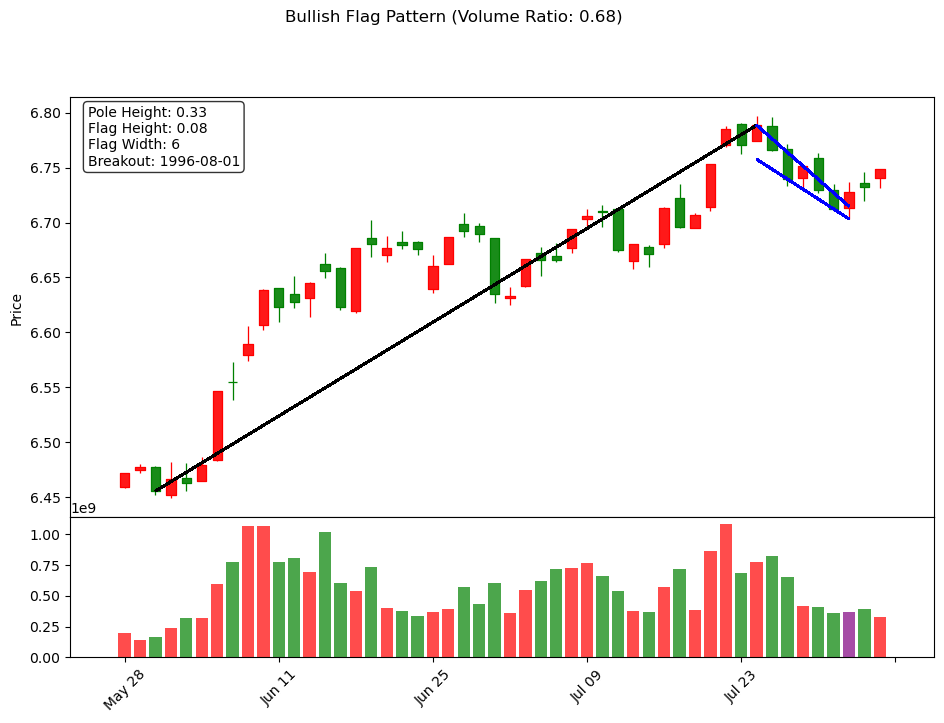

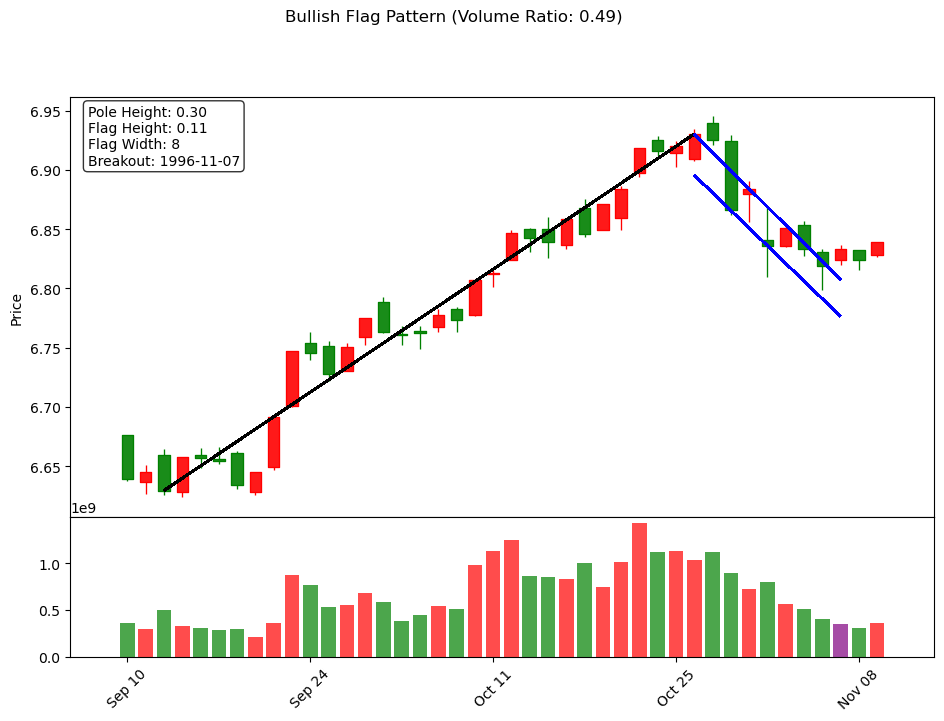

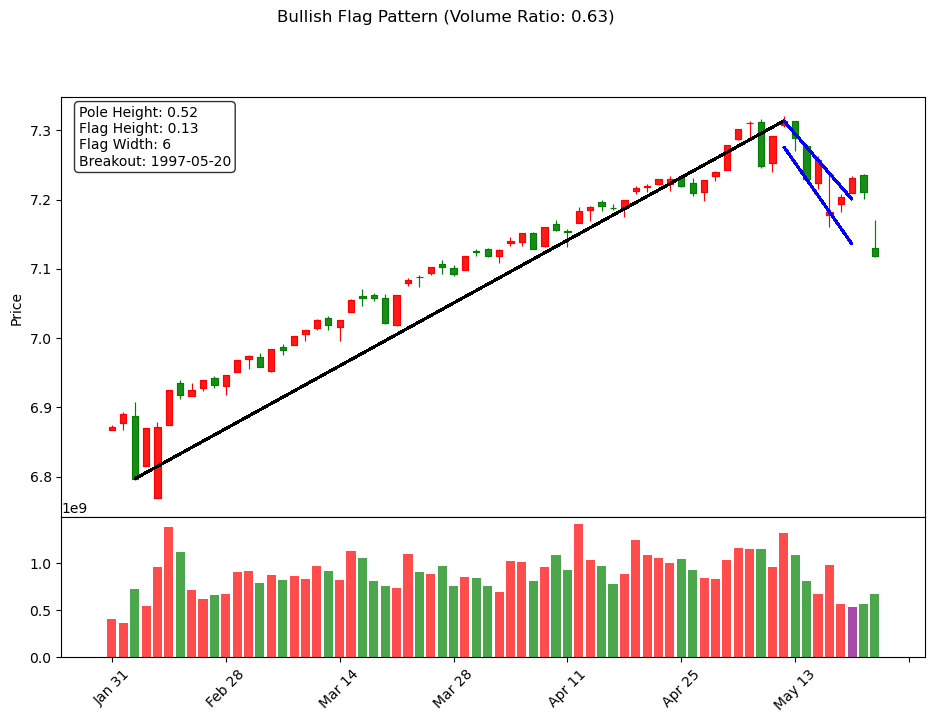

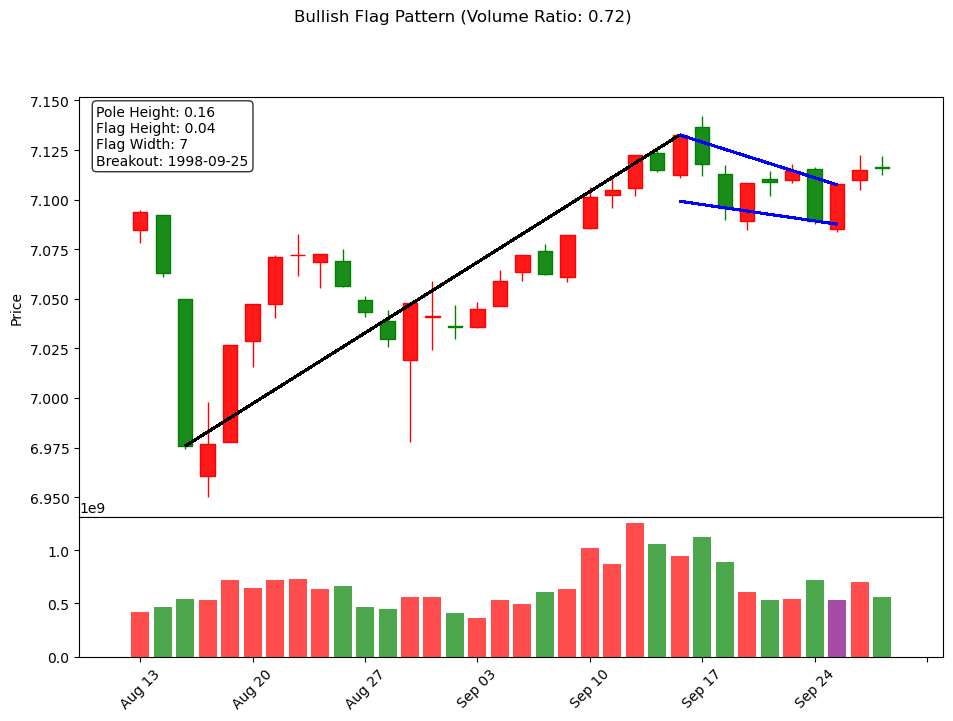

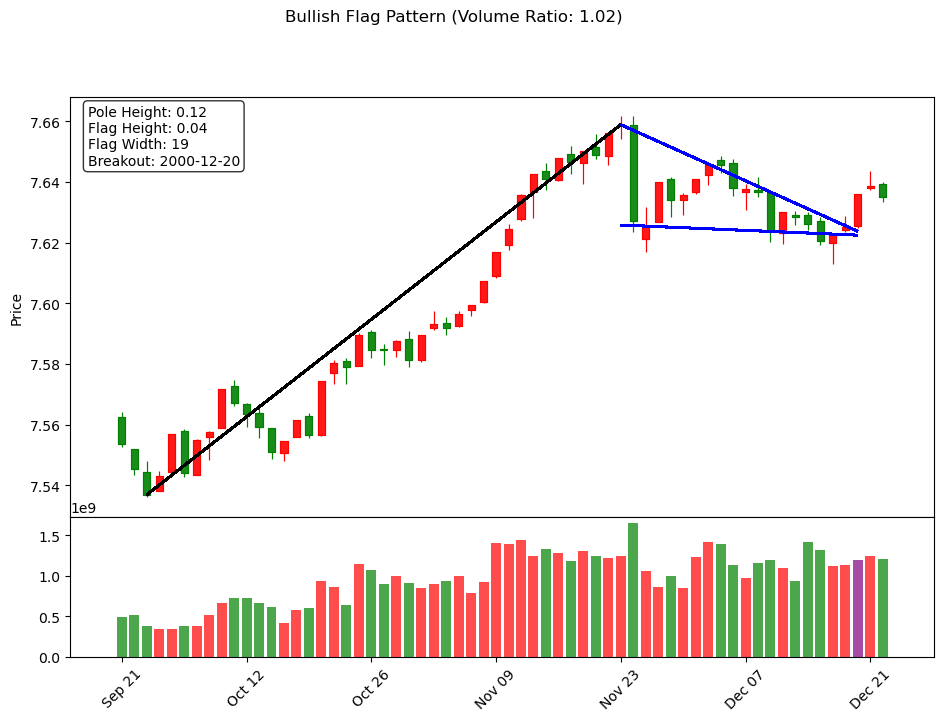

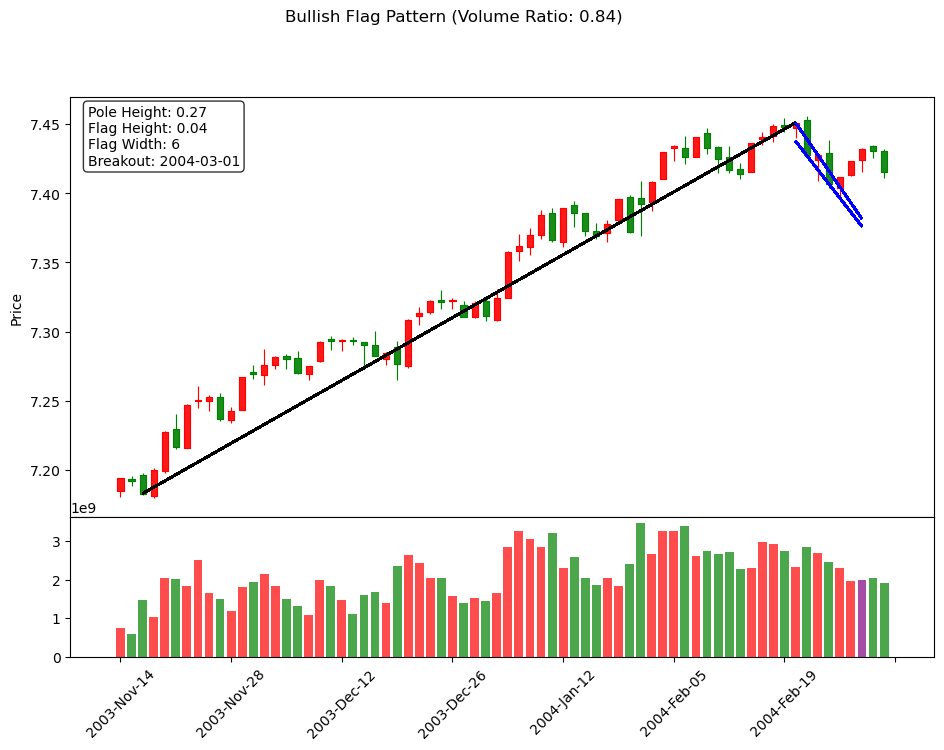

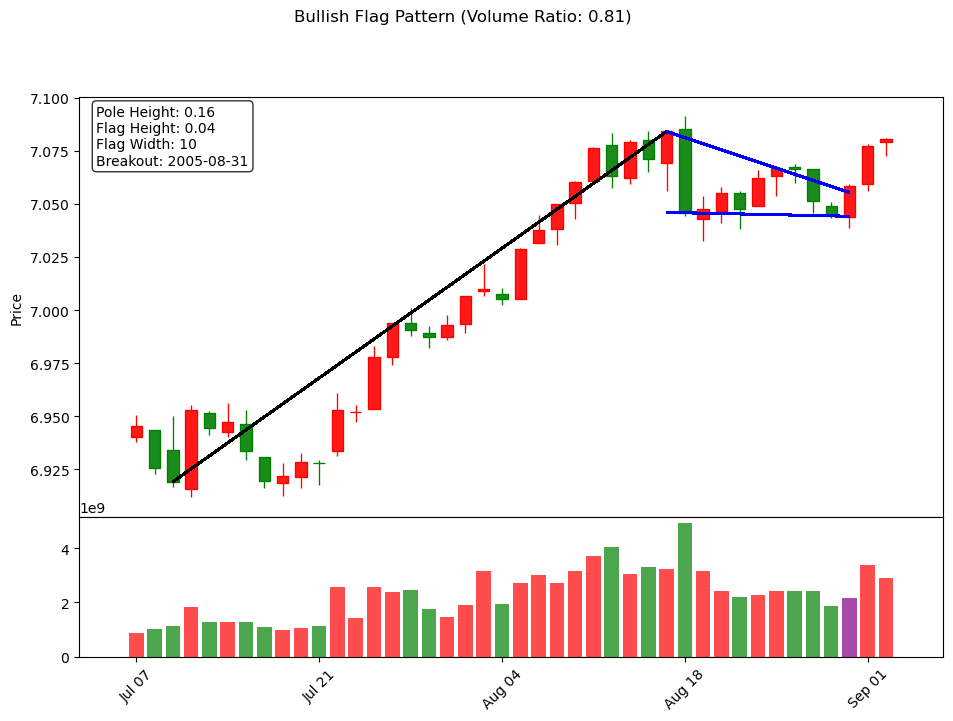

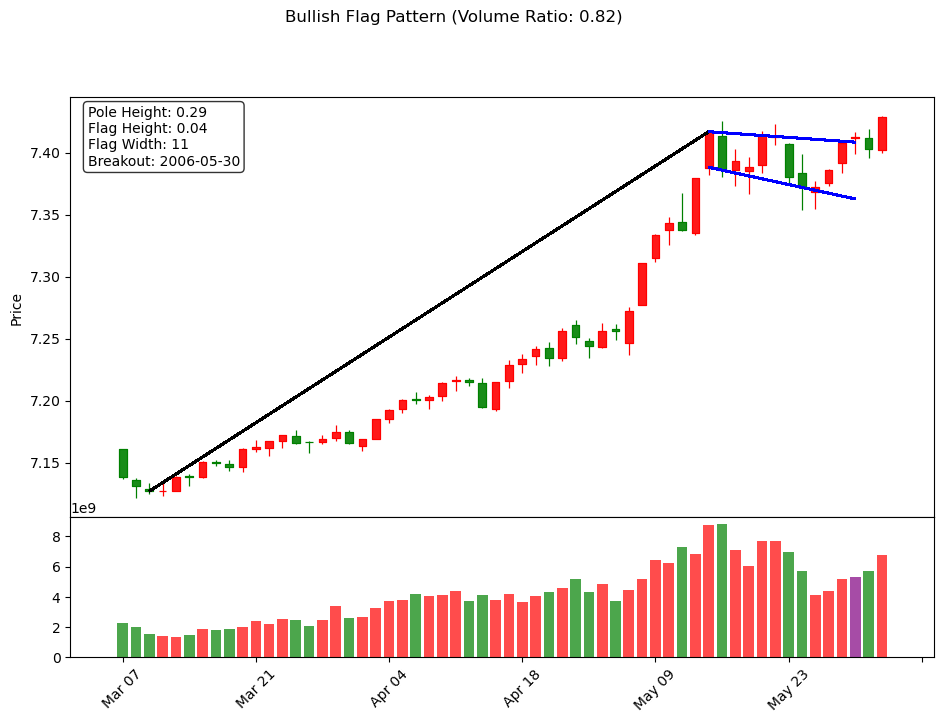

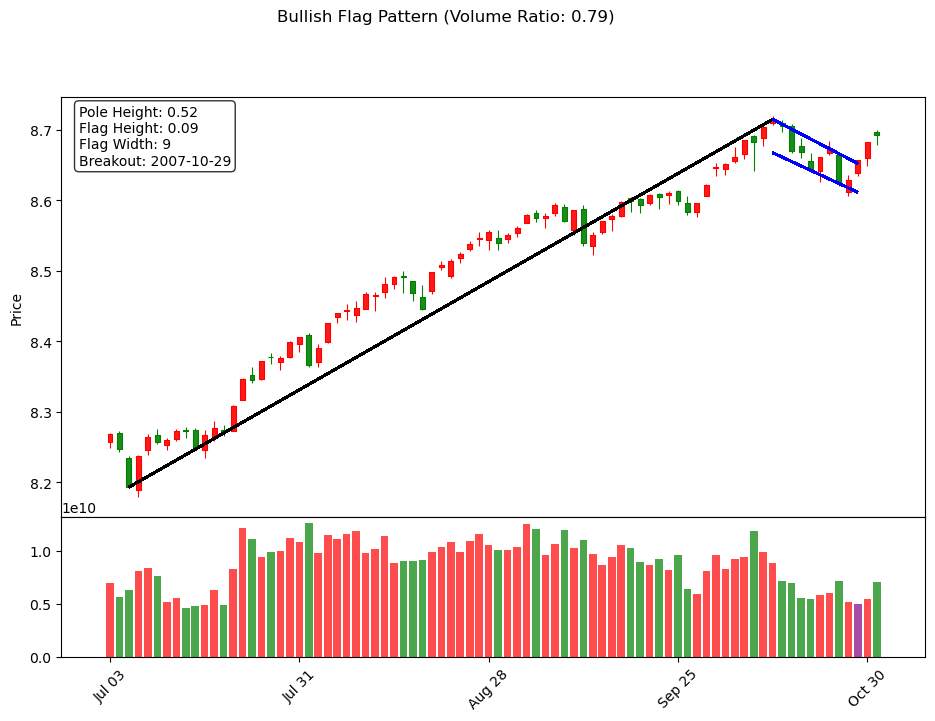

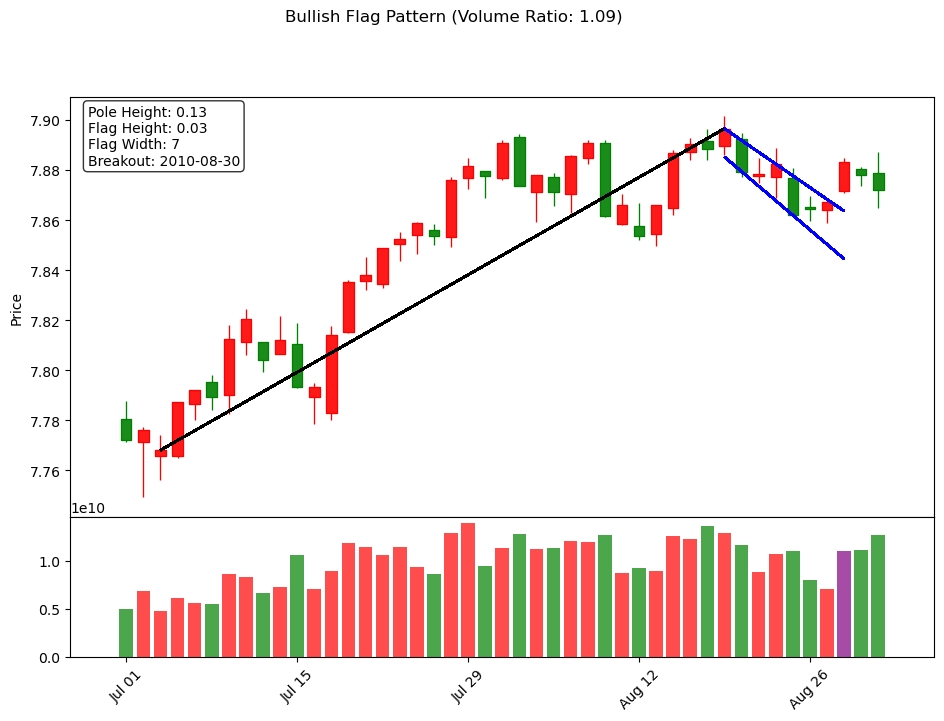

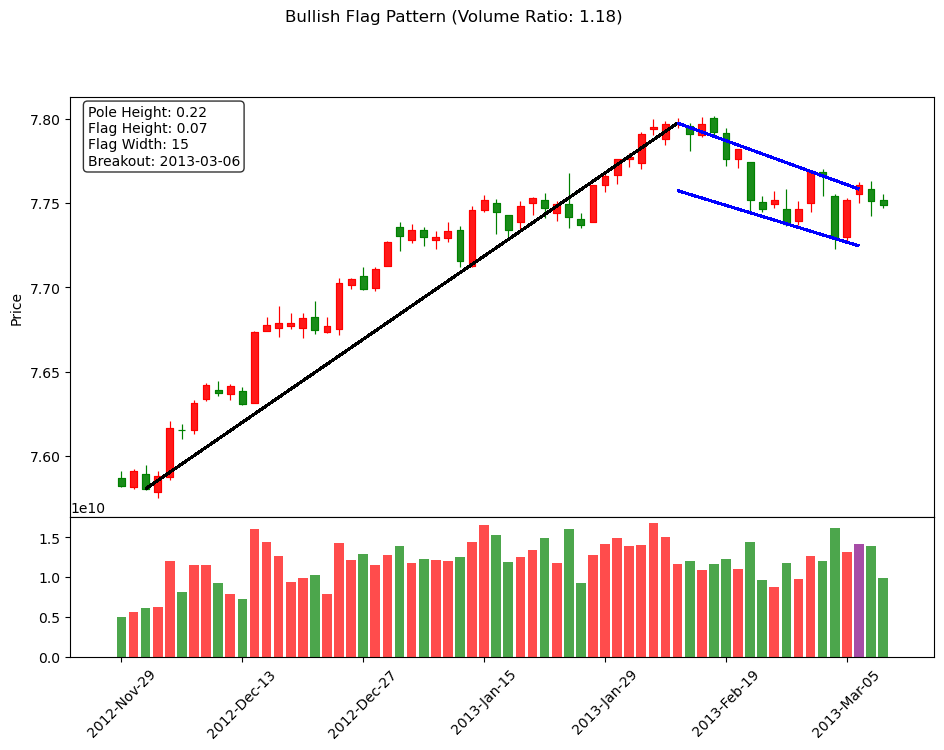

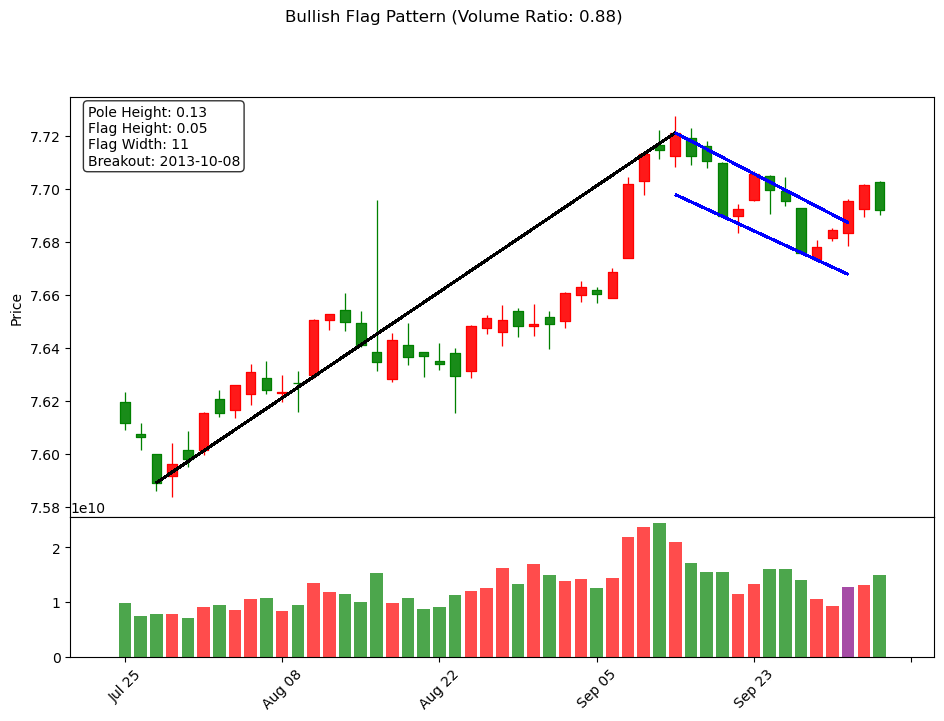

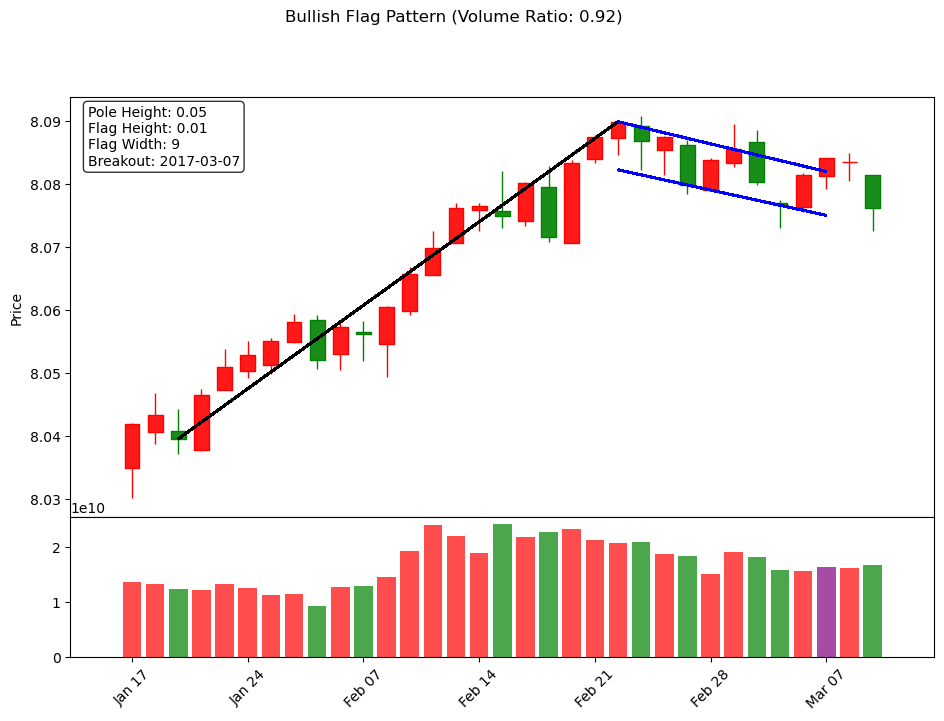

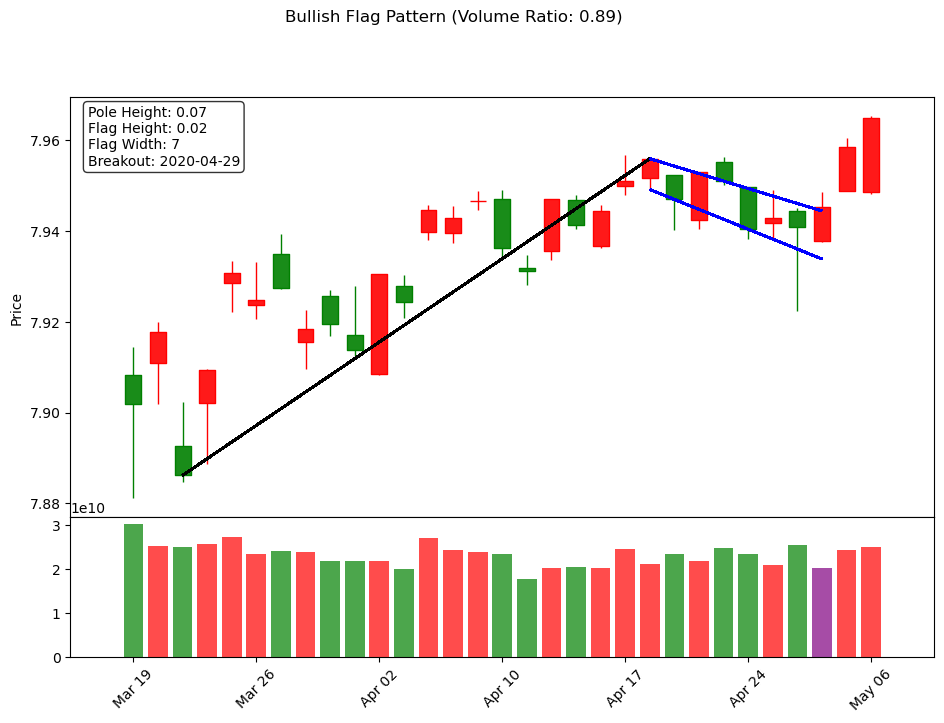

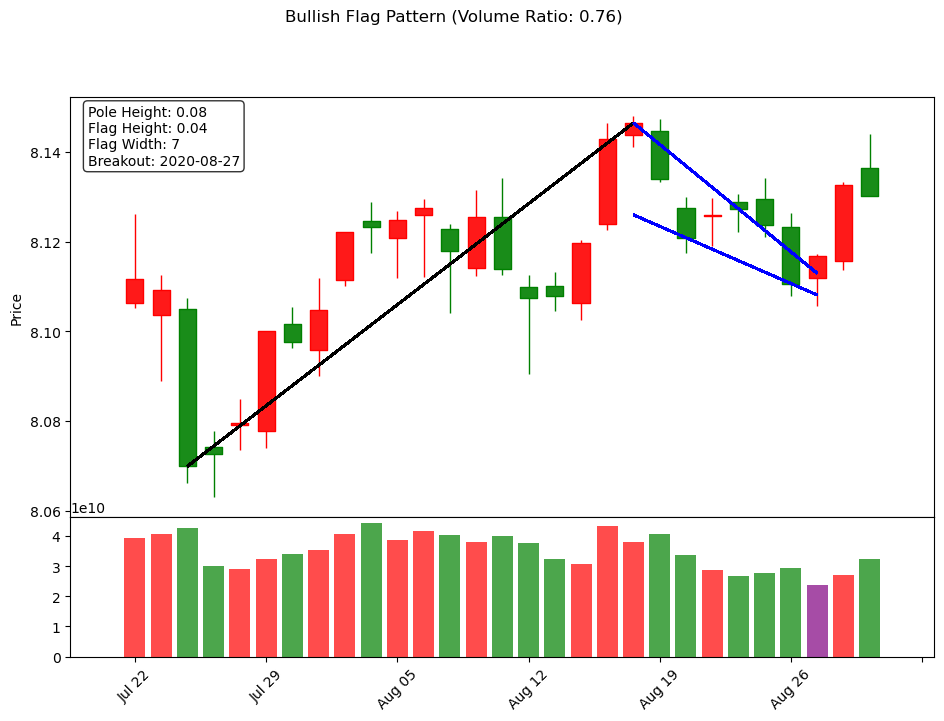

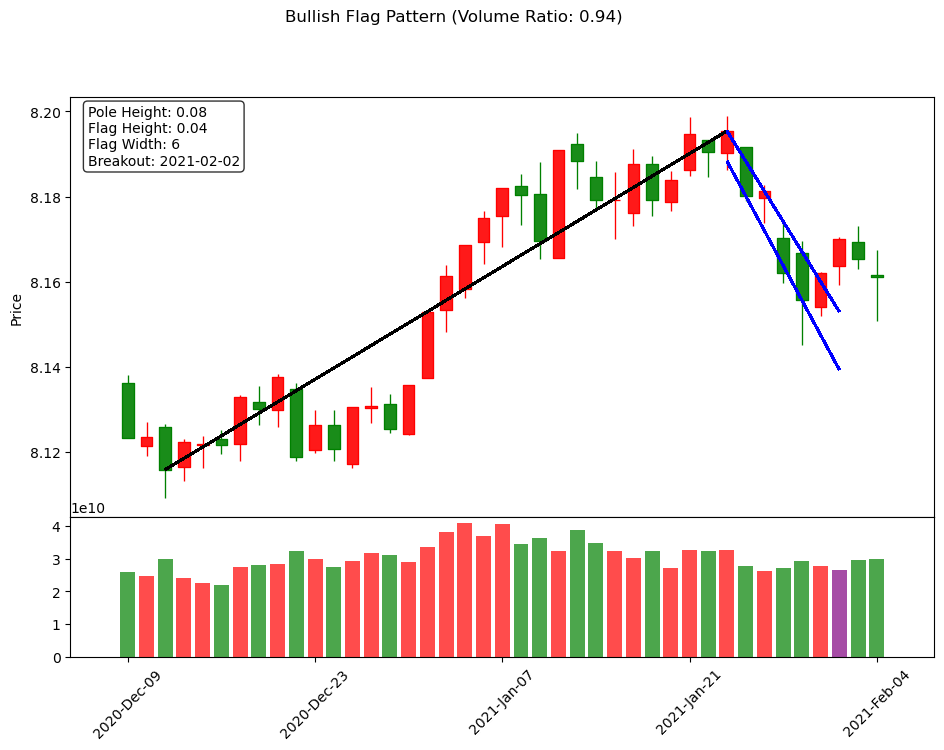

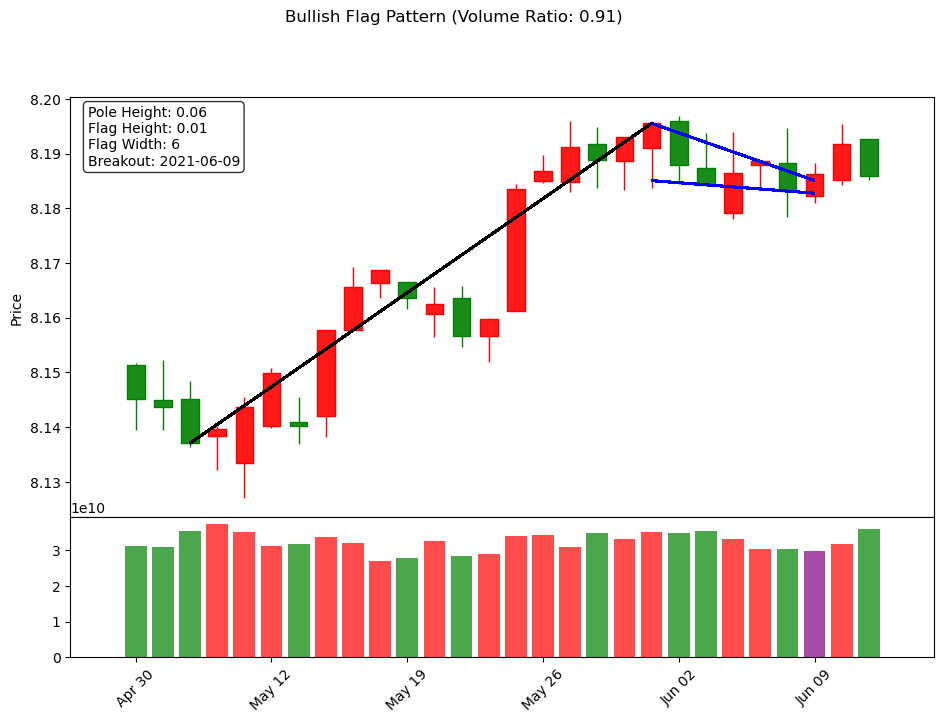


=== 熊市旗形形态统计 ===
共发现熊市旗形数量: 9


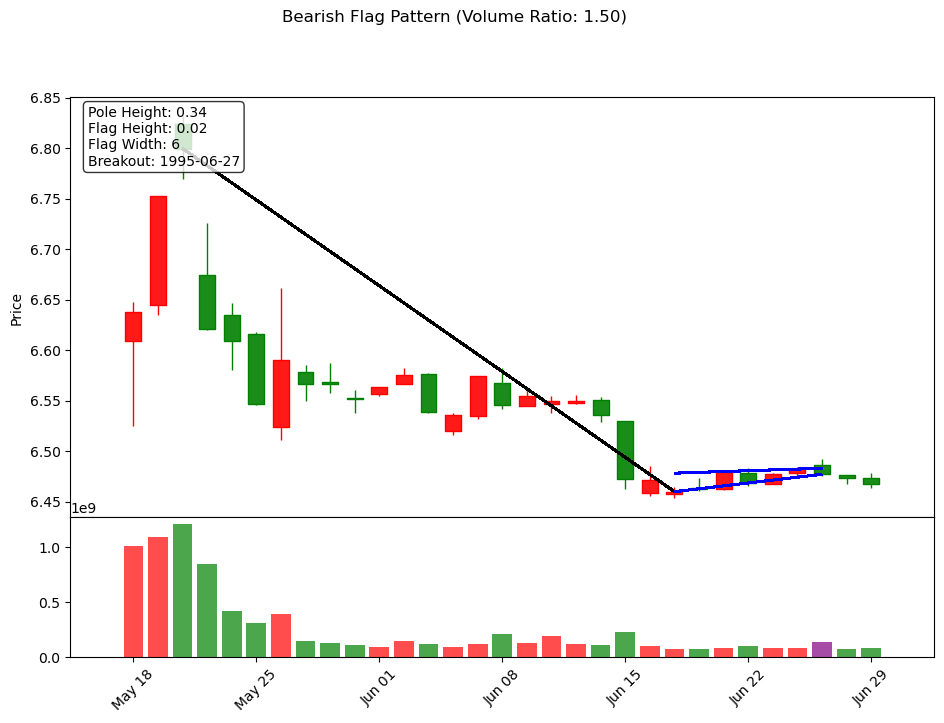

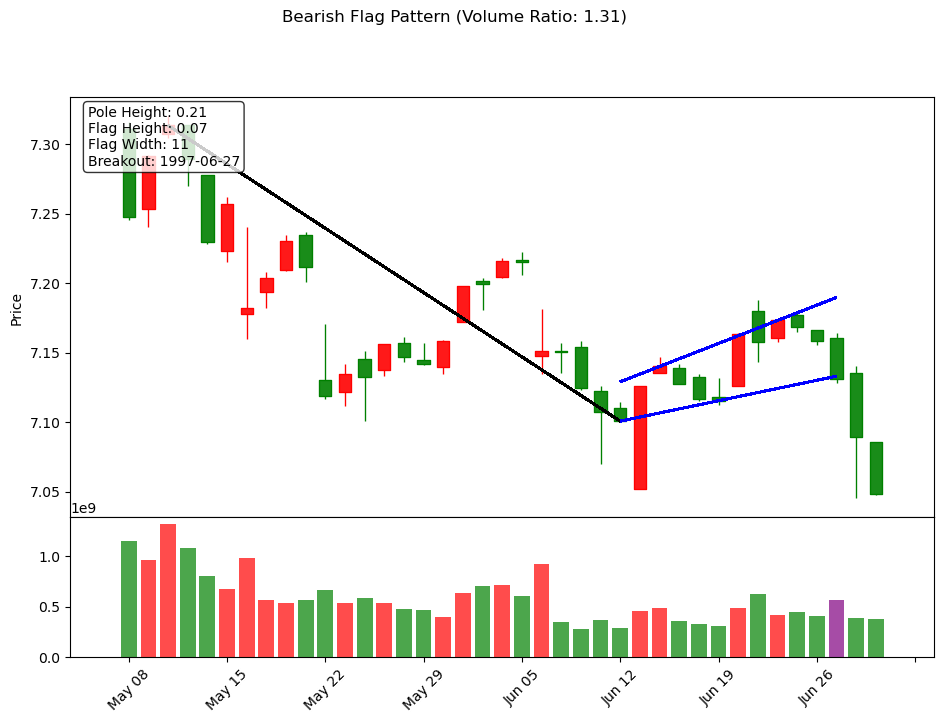

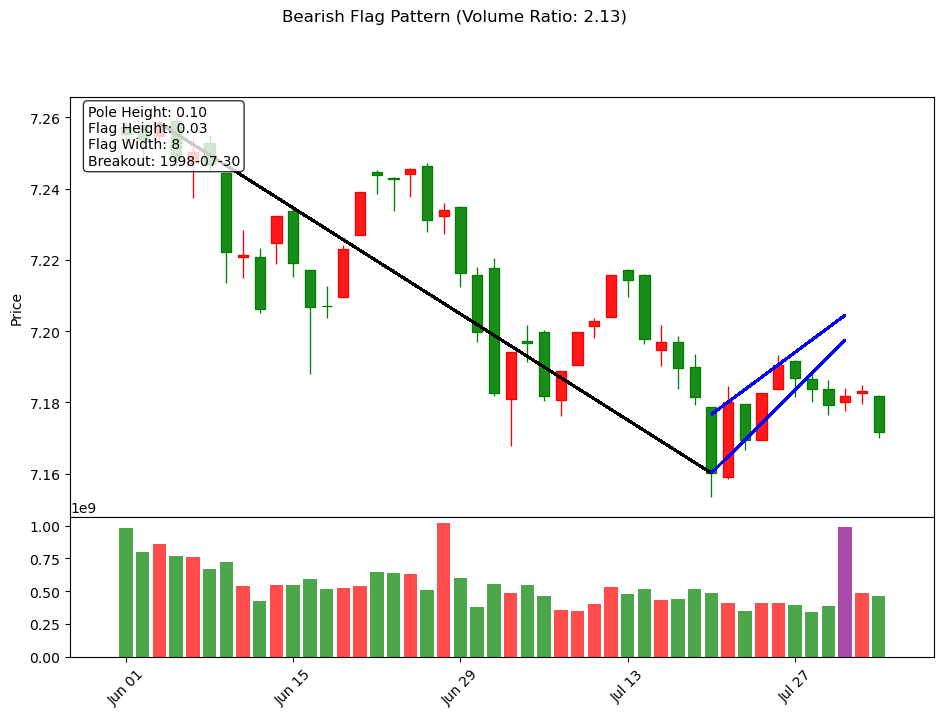

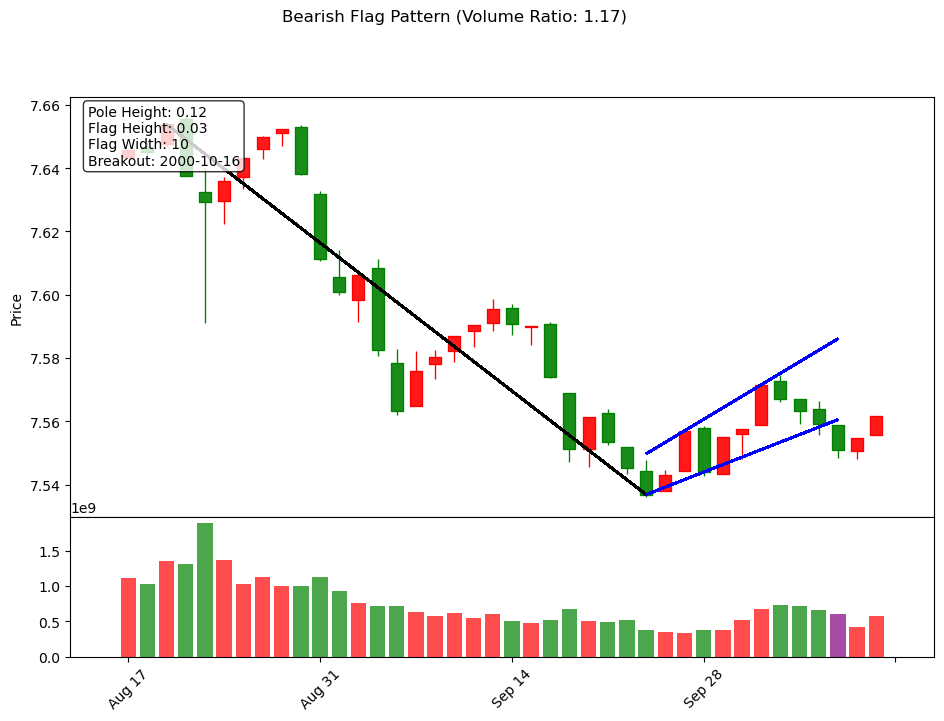

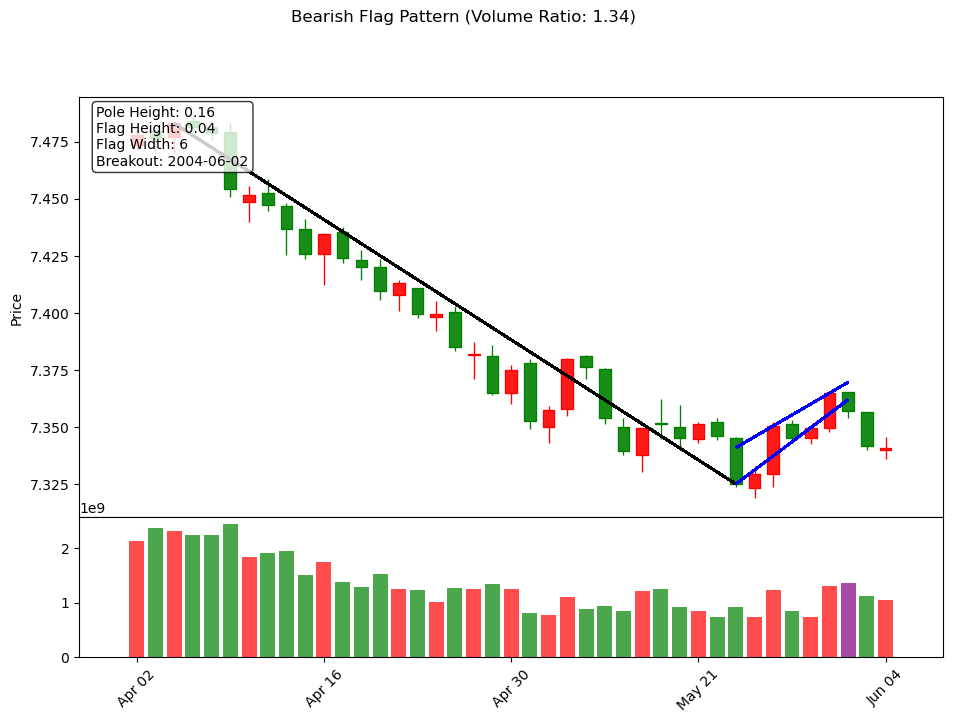

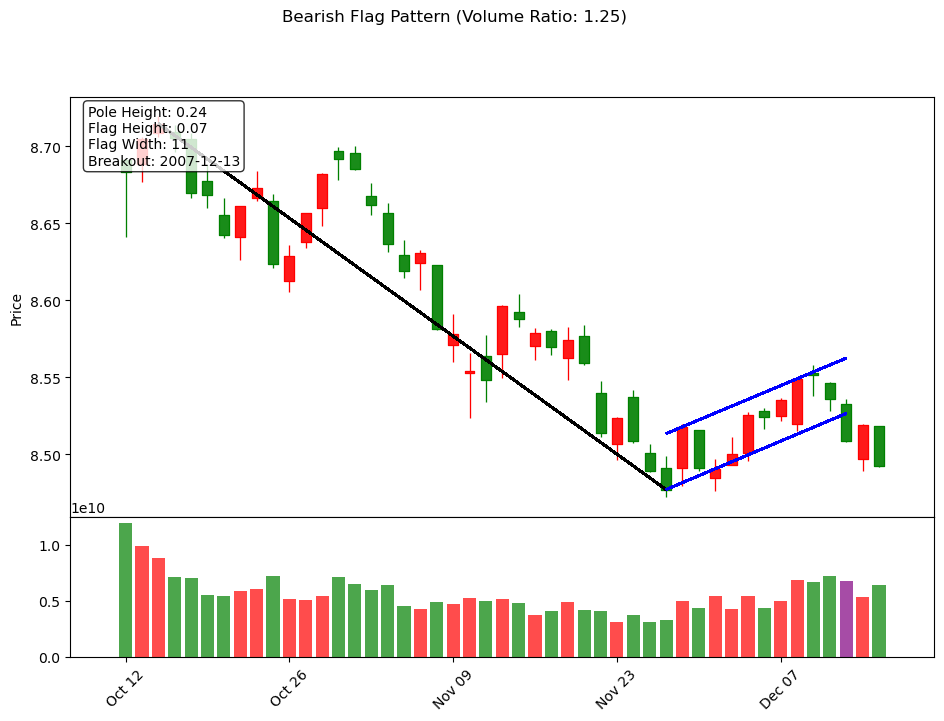

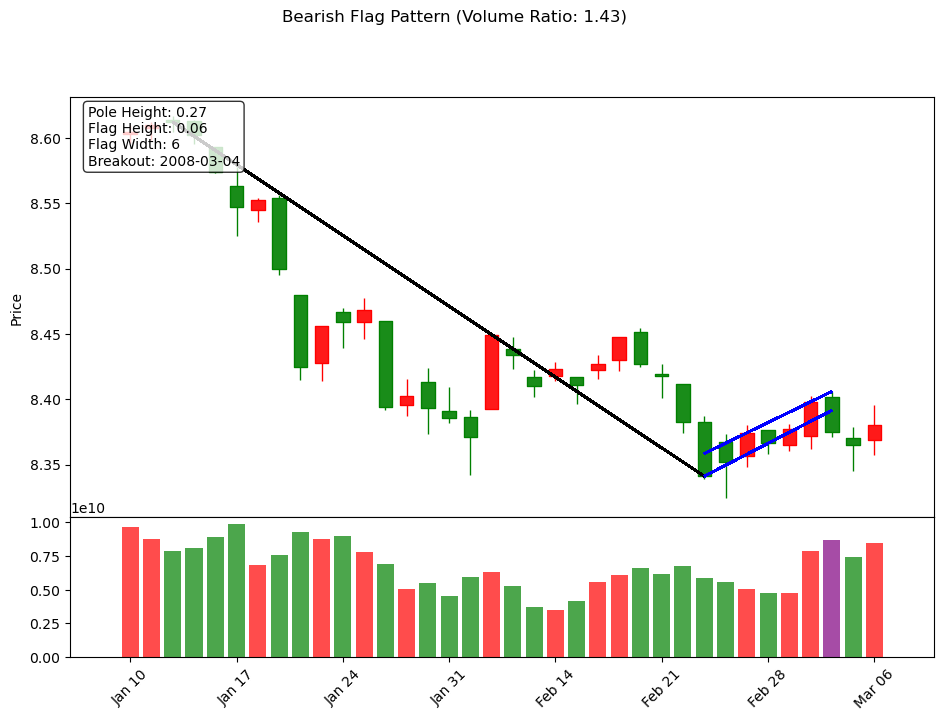

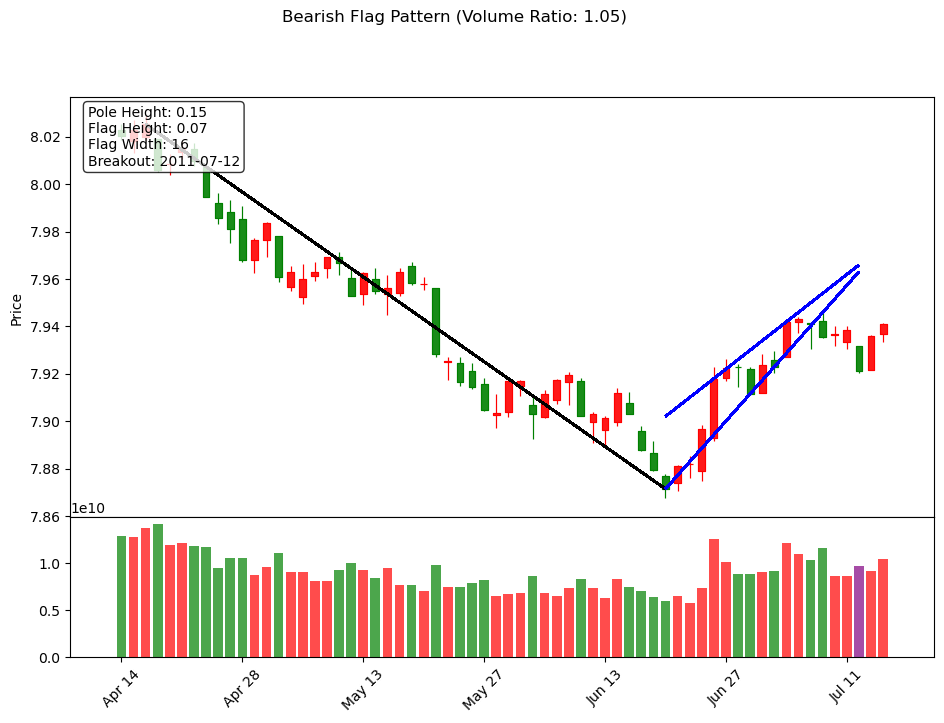

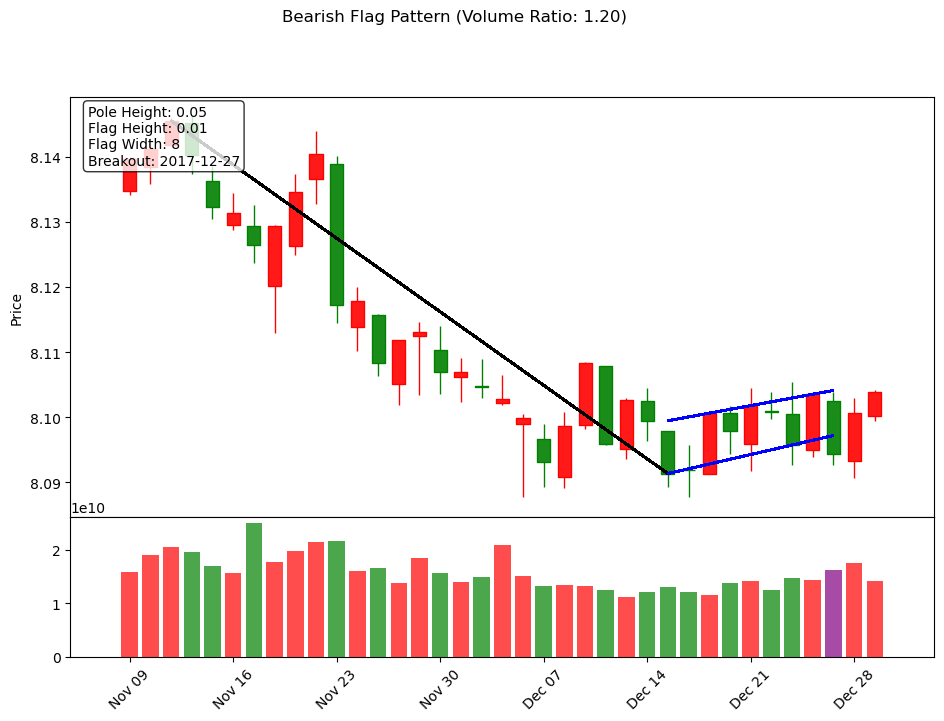


=== 牛市三角旗形态统计 ===
共发现牛市三角旗数量: 6


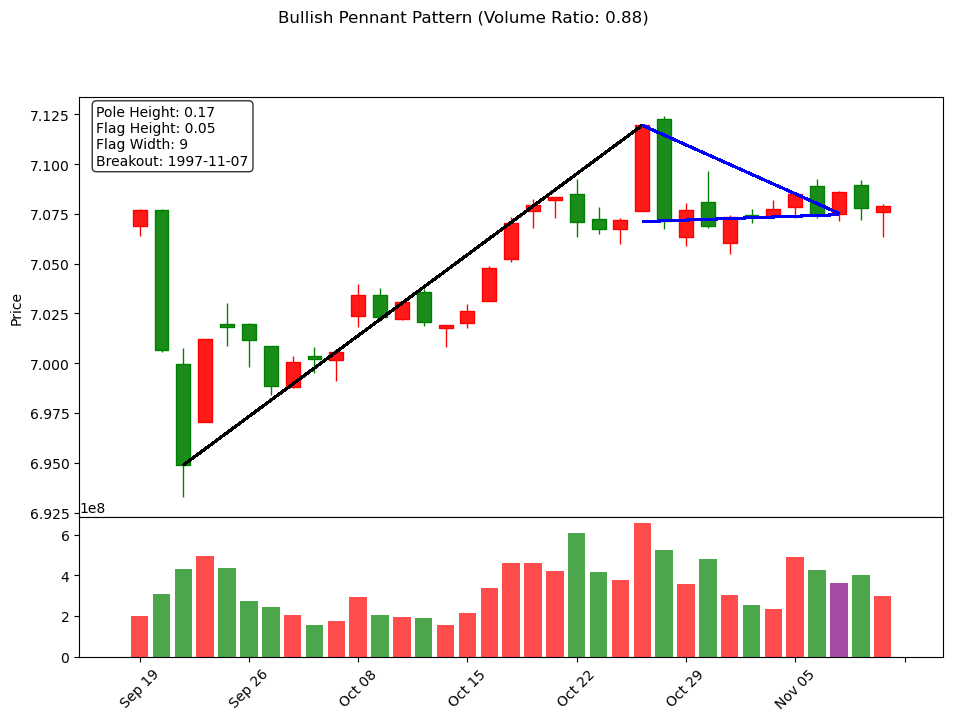

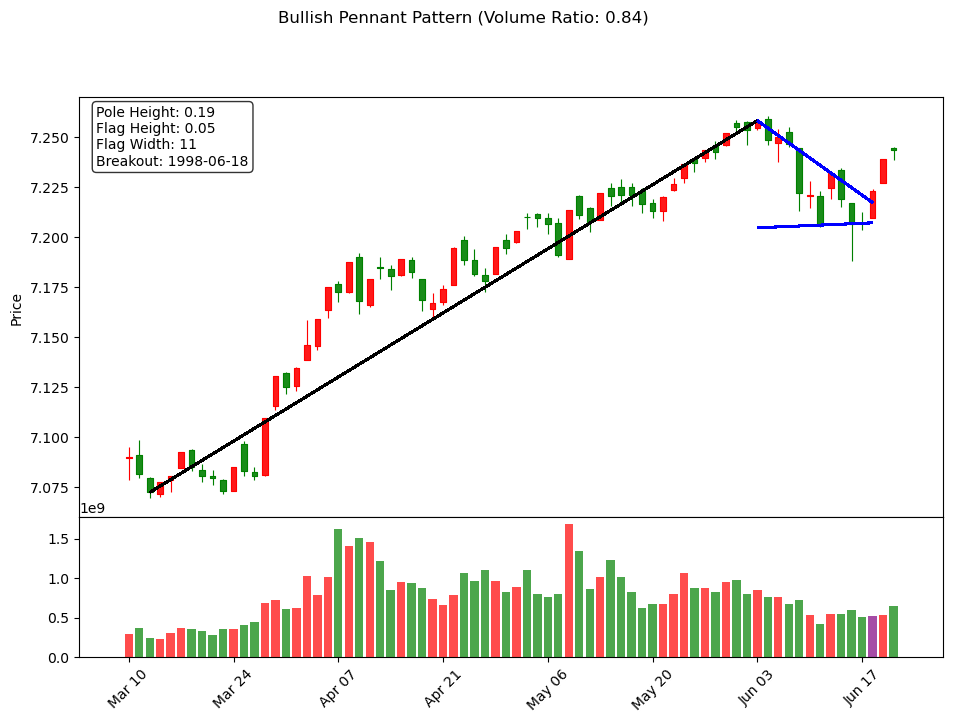

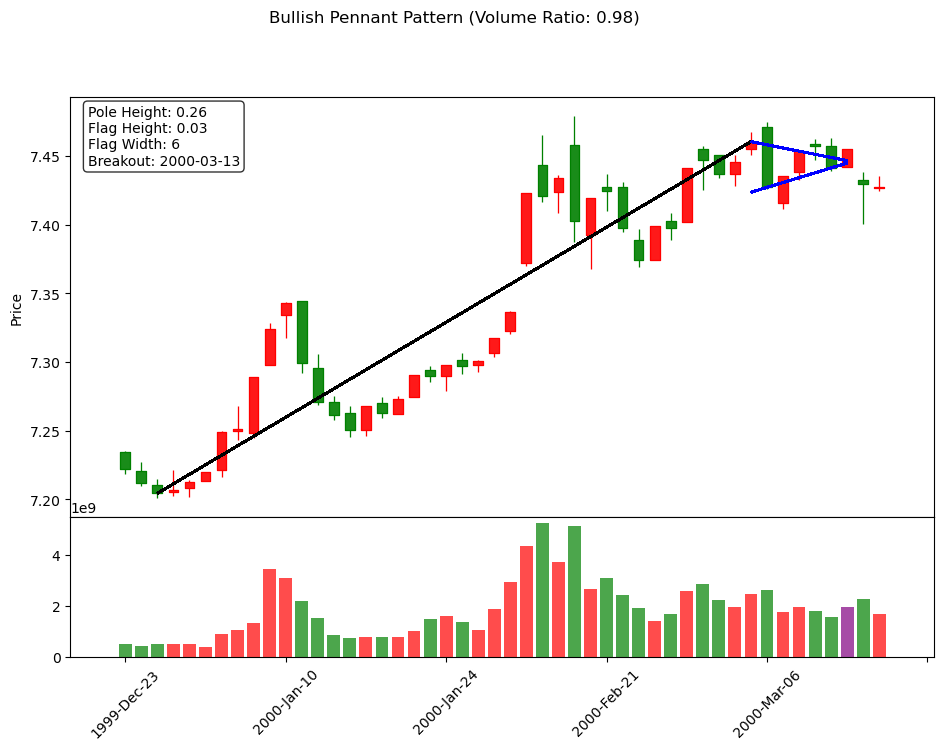

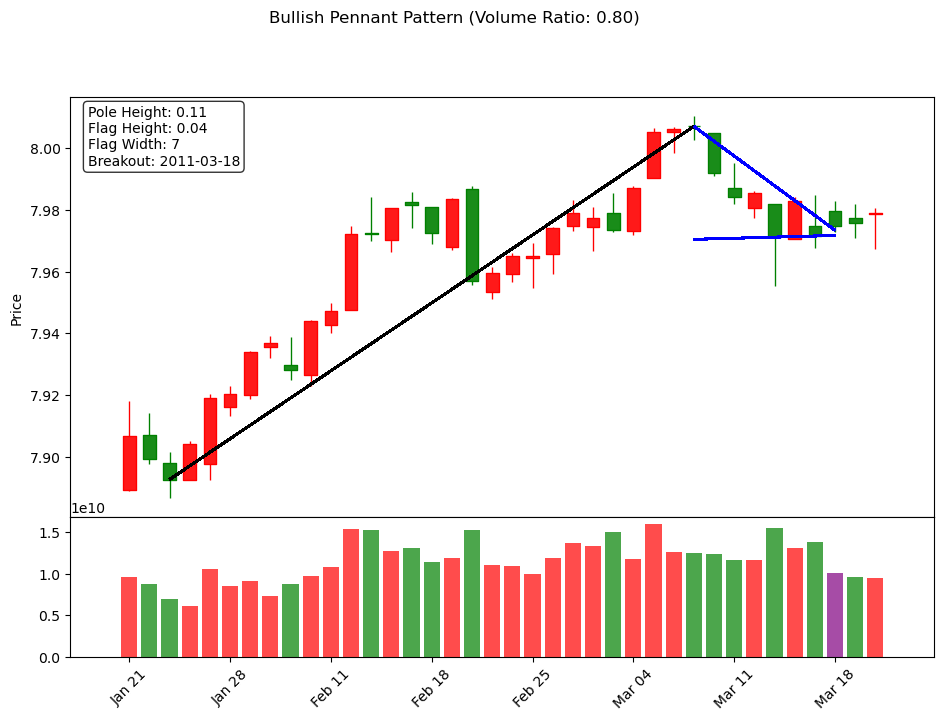

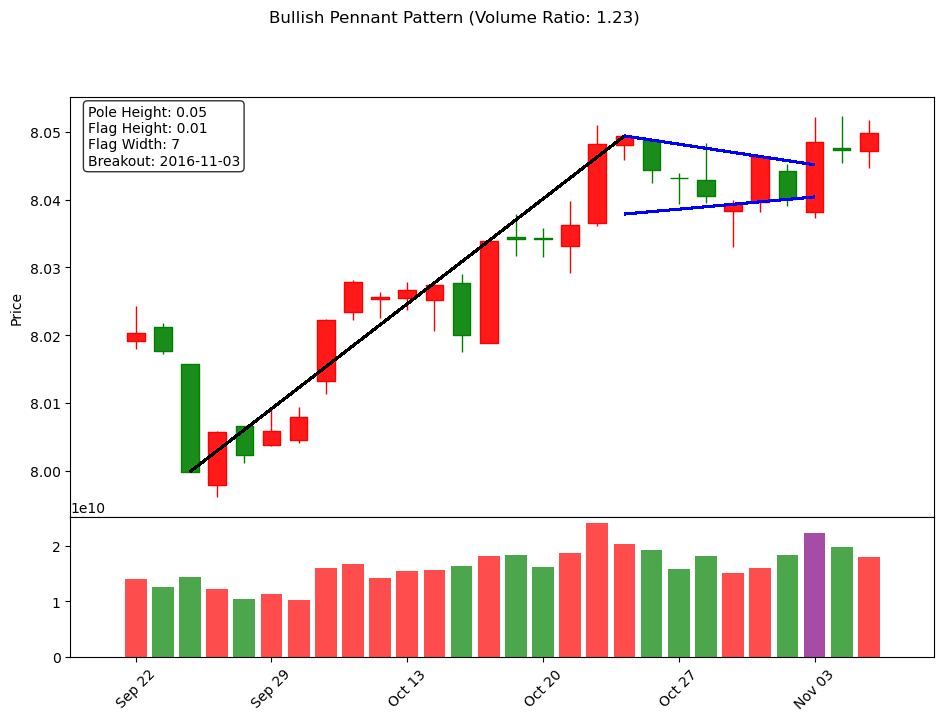

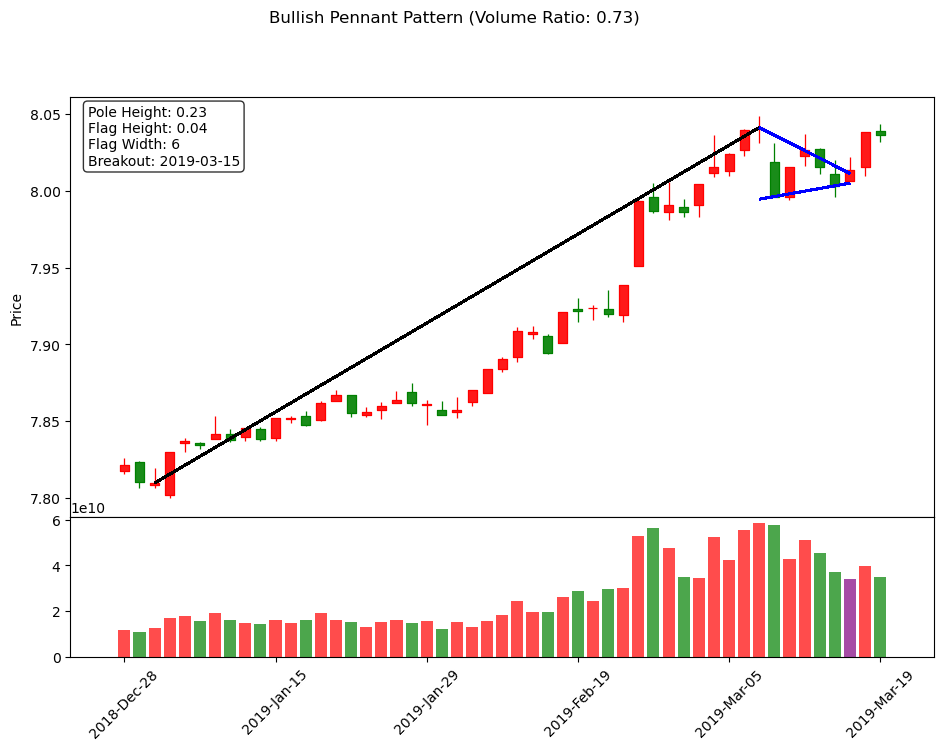


=== 熊市三角旗形态统计 ===
共发现熊市三角旗数量: 2


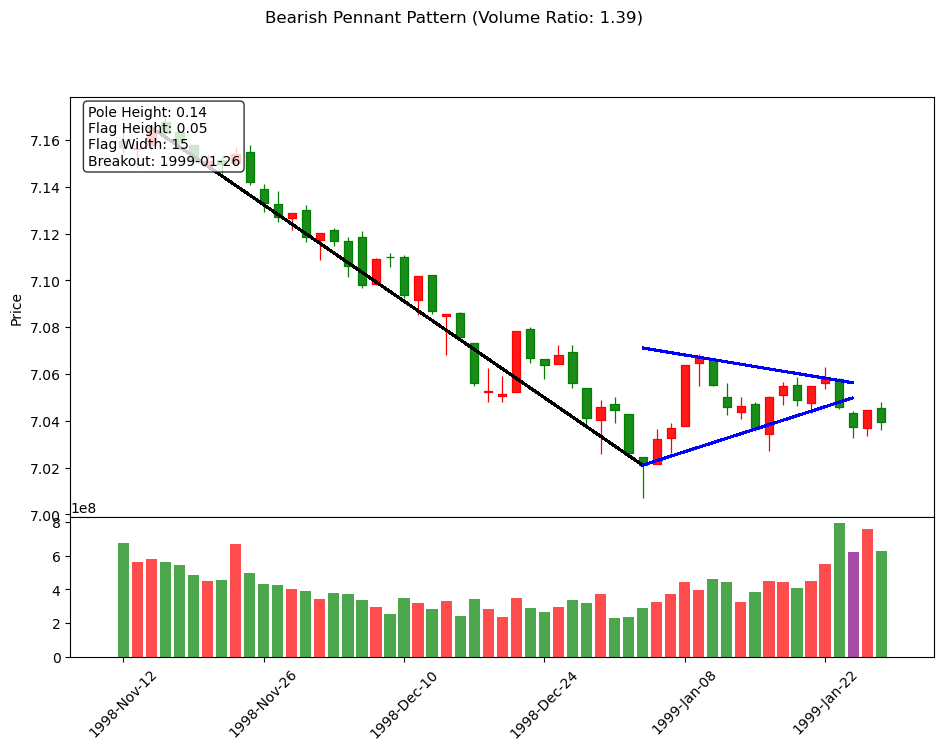

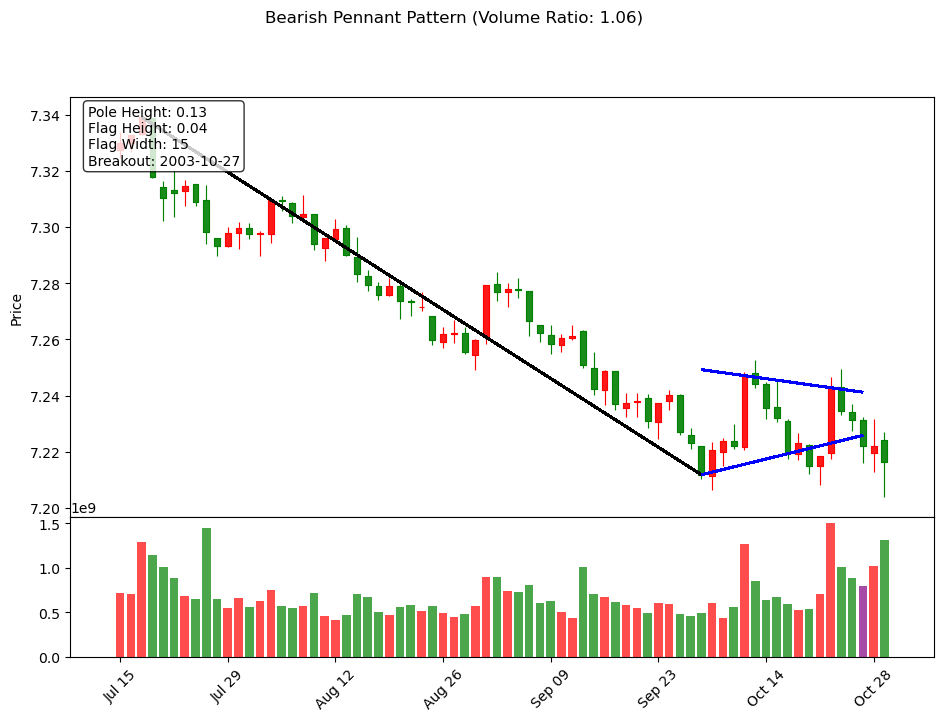

In [7]:
# 主程序（当直接运行此文件时执行）
if __name__ == '__main__':
    # 加载数据
  
    # 对价格取对数
    # 对除Change列外的所有列取对数
    # 将日期索引转换为DatetimeIndex格式
    data.index = pd.to_datetime(data.index).copy()
    
    # 对价格数据取对数，排除Change和Volume列
    data.loc[:, ~data.columns.isin(['Change', 'Volume'])] = np.log(data.loc[:, ~data.columns.isin(['Change', 'Volume'])]).copy()

    # 提取收盘价数据
    price_data = data['Close'].to_numpy().copy()
    volume_data = data['Volume'].to_numpy().copy()

    # 识别旗形和三角旗
    bull_flags, bear_flags, bull_pennants, bear_pennants = find_flags_pennants_pips(price_data, 12, volume_data)  # 使用PIP点方法
    #bull_flags, bear_flags, bull_pennants, bear_pennants = find_flags_pennants_trendline(dat_slice, 10)  # 使用趋势线方法

    # 创建数据框来存储形态属性
    bull_flag_df = pd.DataFrame()
    bull_pennant_df = pd.DataFrame()
    bear_flag_df = pd.DataFrame()
    bear_pennant_df = pd.DataFrame()

    # 将形态数据组织到数据框中
    hold_mult = 1.0  # 持有期乘数（持有时间 = 旗帜宽度 * 乘数）
    
            # 打印牛市旗形形态统计信息
    print("\n=== 牛市旗形形态统计 ===")
    print(f"共发现牛市旗形数量: {len(bull_flags)}")
    # 处理牛市旗形
    for i, flag in enumerate(bull_flags):
        # 记录形态属性
        bull_flag_df.loc[i, 'flag_width'] = flag.flag_width
        bull_flag_df.loc[i, 'flag_height'] = flag.flag_height
        bull_flag_df.loc[i, 'pole_width'] = flag.pole_width
        bull_flag_df.loc[i, 'pole_height'] = flag.pole_height
        bull_flag_df.loc[i, 'slope'] = flag.resist_slope
        bull_flag_df.loc[i, 'conf_price'] = price_data[flag.conf_x]
        bull_flag_df.loc[i, 'date'] = data.index[flag.conf_x]


        # 计算持有期收益
        hp = int(flag.flag_width * hold_mult)
        if flag.conf_x + hp >= len(data):
            bull_flag_df.loc[i, 'return'] = np.nan
        else:
            ret = price_data[flag.conf_x + hp] - price_data[flag.conf_x]
            bull_flag_df.loc[i, 'return'] = ret

        # 绘制牛市旗形
        plot_flag(data, flag)


    # if len(bull_flags) > 0:
    #     print("\n旗形特征统计:")
    #     print(f"旗形宽度均值: {bull_flag_df['flag_width'].mean():.2f}")
    #     print(f"旗形高度均值: {bull_flag_df['flag_height'].mean():.2f}")
    #     print(f"旗杆宽度均值: {bull_flag_df['pole_width'].mean():.2f}")
    #     print(f"旗杆高度均值: {bull_flag_df['pole_height'].mean():.2f}")
    #     print(f"旗形斜率均值: {bull_flag_df['slope'].mean():.4f}")
    #     print(f"\n持有期收益均值: {bull_flag_df['return'].mean():.4f}")
    #     print(f"持有期收益标准差: {bull_flag_df['return'].std():.4f}")

  

    # 处理熊市旗形

    # 打印熊市旗形形态统计信息
    print("\n=== 熊市旗形形态统计 ===")
    print(f"共发现熊市旗形数量: {len(bear_flags)}")

    for i, flag in enumerate(bear_flags):
        # 记录形态属性
        bear_flag_df.loc[i, 'flag_width'] = flag.flag_width
        bear_flag_df.loc[i, 'flag_height'] = flag.flag_height
        bear_flag_df.loc[i, 'pole_width'] = flag.pole_width
        bear_flag_df.loc[i, 'pole_height'] = flag.pole_height
        bear_flag_df.loc[i, 'slope'] = flag.support_slope
        bear_flag_df.loc[i, 'conf_price'] = price_data[flag.conf_x]
        bear_flag_df.loc[i, 'date'] = data.index[flag.conf_x]

        # 计算持有期收益（注意熊市形态是做空，所以收益取负）
        hp = int(flag.flag_width * hold_mult)
        if flag.conf_x + hp >= len(data):
            bear_flag_df.loc[i, 'return'] = np.nan
        else:
            ret = -1 * (price_data[flag.conf_x + hp] - price_data[flag.conf_x])
            bear_flag_df.loc[i, 'return'] = ret 

        # 绘制熊市旗形
        plot_flag(data, flag)


    # if len(bear_flags) > 0:
    #     print("\n旗形特征统计:")
    #     print(f"旗形宽度均值: {bear_flag_df['flag_width'].mean():.2f}")
    #     print(f"旗形高度均值: {bear_flag_df['flag_height'].mean():.2f}")
    #     print(f"旗杆宽度均值: {bear_flag_df['pole_width'].mean():.2f}")
    #     print(f"旗杆高度均值: {bear_flag_df['pole_height'].mean():.2f}")
    #     print(f"旗形斜率均值: {bear_flag_df['slope'].mean():.4f}")
    #     print(f"\n持有期收益均值: {bear_flag_df['return'].mean():.4f}")
    #     print(f"持有期收益标准差: {bear_flag_df['return'].std():.4f}")

                 # 打印牛市三角旗形态统计信息
    print("\n=== 牛市三角旗形态统计 ===")
    print(f"共发现牛市三角旗数量: {len(bull_pennants)}")
    # 处理牛市三角旗
    for i, pennant in enumerate(bull_pennants):
        # 记录形态属性
        bull_pennant_df.loc[i, 'pennant_width'] = pennant.flag_width
        bull_pennant_df.loc[i, 'pennant_height'] = pennant.flag_height
        bull_pennant_df.loc[i, 'pole_width'] = pennant.pole_width
        bull_pennant_df.loc[i, 'pole_height'] = pennant.pole_height
        bull_pennant_df.loc[i, 'conf_price'] = price_data[pennant.conf_x]
        bull_pennant_df.loc[i, 'date'] = data.index[pennant.conf_x]

        # 计算持有期收益
        hp = int(pennant.flag_width * hold_mult)
        if pennant.conf_x + hp >= len(data):
            bull_pennant_df.loc[i, 'return'] = np.nan
        else:
            ret = price_data[pennant.conf_x + hp] - price_data[pennant.conf_x]
            bull_pennant_df.loc[i, 'return'] = ret 

        # 绘制牛市三角旗
        plot_flag(data, pennant)


    # if len(bull_pennants) > 0:
    #     print("\n三角旗特征统计:")
    #     print(f"三角旗宽度均值: {bull_pennant_df['pennant_width'].mean():.2f}")
    #     print(f"三角旗高度均值: {bull_pennant_df['pennant_height'].mean():.2f}")
    #     print(f"旗杆宽度均值: {bull_pennant_df['pole_width'].mean():.2f}")
    #     print(f"旗杆高度均值: {bull_pennant_df['pole_height'].mean():.2f}")
    #     print(f"\n持有期收益均值: {bull_pennant_df['return'].mean():.4f}")
    #     print(f"持有期收益标准差: {bull_pennant_df['return'].std():.4f}")


                         # 打印熊市三角旗形态统计信息
    print("\n=== 熊市三角旗形态统计 ===")
    print(f"共发现熊市三角旗数量: {len(bear_pennants)}")
    # 处理熊市三角旗
    for i, pennant in enumerate(bear_pennants):
        # 记录形态属性
        bear_pennant_df.loc[i, 'pennant_width'] = pennant.flag_width
        bear_pennant_df.loc[i, 'pennant_height'] = pennant.flag_height
        bear_pennant_df.loc[i, 'pole_width'] = pennant.pole_width
        bear_pennant_df.loc[i, 'pole_height'] = pennant.pole_height
        bear_pennant_df.loc[i, 'conf_price'] = price_data[pennant.conf_x]
        bear_pennant_df.loc[i, 'date'] = data.index[pennant.conf_x]

        # 计算持有期收益（注意熊市形态是做空，所以收益取负）
        hp = int(pennant.flag_width * hold_mult)
        if pennant.conf_x + hp >= len(data):
            bear_pennant_df.loc[i, 'return'] = np.nan
        else:
            ret = -1 * (price_data[pennant.conf_x + hp] - price_data[pennant.conf_x])
            bear_pennant_df.loc[i, 'return'] = ret 

        # 绘制熊市三角旗
        plot_flag(data, pennant)


    # if len(bear_pennants) > 0:
    #     print("\n三角旗特征统计:")
    #     print(f"三角旗宽度均值: {bear_pennant_df['pennant_width'].mean():.2f}")
    #     print(f"三角旗高度均值: {bear_pennant_df['pennant_height'].mean():.2f}")
    #     print(f"旗杆宽度均值: {bear_pennant_df['pole_width'].mean():.2f}")
    #     print(f"旗杆高度均值: {bear_pennant_df['pole_height'].mean():.2f}")
    #     print(f"\n持有期收益均值: {bear_pennant_df['return'].mean():.4f}")
    #     print(f"持有期收益标准差: {bear_pennant_df['return'].std():.4f}")


<font color=steel size=5 face=雅黑>3.将旗形绘制到同一坐标系下</font>

In [8]:
def plot_all_flags(candle_data: pd.DataFrame, patterns_list, pattern_names, pad=2):
    """
    在同一个图中绘制所有旗形
    
    参数:
    candle_data: pd.DataFrame - K线数据
    patterns_list: list - 包含所有形态的列表 [bull_flags, bear_flags, bull_pennants, bear_pennants]
    pattern_names: list - 形态名称列表
    pad: int - 图表两侧的额外空间
    """
    # 创建图表对象
    fig = go.Figure()
    
    # 找出所有形态的最早和最晚时间点
    min_base_x = float('inf')
    max_conf_x = 0
    for patterns in patterns_list:
        for pattern in patterns:
            min_base_x = min(min_base_x, pattern.base_x)
            max_conf_x = max(max_conf_x, pattern.conf_x)
    
    # 使用原始数据
    dat = candle_data
    
    # 添加K线图
    fig.add_trace(go.Candlestick(
        x=dat.index,
        open=dat['Open'],
        high=dat['High'],
        low=dat['Low'],
        close=dat['Close'],
        name='K线'
    ))
    
    # 定义不同形态的颜色
    colors = ['red', 'green', 'blue', 'orange']
    
    # 为每种形态添加线条
    for patterns, pattern_name, color in zip(patterns_list, pattern_names, colors):
        # 用于存储所有同类型的线条
        pole_lines = []
        resist_lines = []
        support_lines = []
        key_points = []
        
        for pattern in patterns:
            # 获取相对于显示范围的索引
            base_idx = candle_data.index[pattern.base_x]
            tip_idx = candle_data.index[pattern.tip_x]
            conf_idx = candle_data.index[pattern.conf_x]
            
            # 收集旗杆线数据
            pole_lines.extend([
                [base_idx, pattern.base_y],
                [tip_idx, pattern.tip_y],
                [None, None]  # 用于分隔不同的线段
            ])
            
            # 收集阻力线数据
            resist_y = [pattern.resist_intercept, 
                       pattern.resist_intercept + pattern.resist_slope * pattern.flag_width]
            resist_lines.extend([
                [tip_idx, resist_y[0]],
                [conf_idx, resist_y[1]],
                [None, None]
            ])
            
            # 收集支撑线数据
            support_y = [pattern.support_intercept,
                        pattern.support_intercept + pattern.support_slope * pattern.flag_width]
            support_lines.extend([
                [tip_idx, support_y[0]],
                [conf_idx, support_y[1]],
                [None, None]
            ])
            
            # 收集关键点数据
            key_points.extend([
                [base_idx, pattern.base_y],
                [tip_idx, pattern.tip_y],
                [conf_idx, pattern.conf_y],
                [None, None]
            ])
        
        # 添加所有旗杆线
        if pole_lines:
            x_poles, y_poles = zip(*pole_lines)
            fig.add_trace(go.Scatter(
                x=x_poles, y=y_poles,
                mode='lines',
                line=dict(color=color, width=2),
                name=f'{pattern_name}-旗杆'
            ))
        
        # 添加所有阻力线
        if resist_lines:
            x_resist, y_resist = zip(*resist_lines)
            fig.add_trace(go.Scatter(
                x=x_resist, y=y_resist,
                mode='lines',
                line=dict(color=color, dash='dash'),
                name=f'{pattern_name}-趋势线'
            ))
        
        # 添加所有支撑线
        if support_lines:
            x_support, y_support = zip(*support_lines)
            fig.add_trace(go.Scatter(
                x=x_support, y=y_support,
                mode='lines',
                line=dict(color=color, dash='dash'),
                showlegend=False  # 不显示支撑线的图例（与阻力线共用一个）
            ))
        
        # 添加所有关键点
        if key_points:
            x_points, y_points = zip(*key_points)
            fig.add_trace(go.Scatter(
                x=x_points, y=y_points,
                mode='markers',
                marker=dict(size=8, color=color),
                name=f'{pattern_name}-关键点'
            ))
    
    # 更新图表布局
    fig.update_layout(
        template='plotly',
        xaxis_title='日期',
        yaxis_title='价格',
        showlegend=True,
        height=800,
        title='旗形与三角旗形态识别'
    )
    
    # 添加范围滑块
    fig.update_xaxes(rangeslider_visible=True)
    
    return fig

# 使用示例：
pattern_names = ['牛市旗形', '熊市旗形', '牛市三角旗', '熊市三角旗']
patterns_list = [bull_flags, bear_flags, bull_pennants, bear_pennants]

# 绘制图形
fig = plot_all_flags(data, patterns_list, pattern_names)
fig.show()

<font color=steel size=5 face=雅黑>3.将旗形绘制到同一坐标系下（只用收盘价）</font>

In [9]:
def plot_all_flags(candle_data: pd.DataFrame, patterns_list, pattern_names, pad=2):
    """
    在同一个图中绘制所有旗形,只使用收盘价
    
    参数:
    candle_data: pd.DataFrame - K线数据
    patterns_list: list - 包含所有形态的列表 [bull_flags, bear_flags, bull_pennants, bear_pennants]
    pattern_names: list - 形态名称列表
    pad: int - 图表两侧的额外空间
    """
    # 创建图表对象
    fig = go.Figure()
    
    # 找出所有形态的最早和最晚时间点
    min_base_x = float('inf')
    max_conf_x = 0
    for patterns in patterns_list:
        for pattern in patterns:
            min_base_x = min(min_base_x, pattern.base_x)
            max_conf_x = max(max_conf_x, pattern.conf_x)
    
    # 使用原始数据
    dat = candle_data
    
    # 添加收盘价线图
    fig.add_trace(go.Scatter(
        x=dat.index,
        y=dat['Close'],
        mode='lines',
        name='收盘价',
        line=dict(color='black', width=1)
    ))
    
    # 定义不同形态的颜色
    colors = ['red', 'green', 'blue', 'orange']
    
    # 为每种形态添加线条
    for patterns, pattern_name, color in zip(patterns_list, pattern_names, colors):
        # 用于存储所有同类型的线条
        pole_lines = []
        resist_lines = []
        support_lines = []
        key_points = []
        
        for pattern in patterns:
            # 获取相对于显示范围的索引
            base_idx = candle_data.index[pattern.base_x]
            tip_idx = candle_data.index[pattern.tip_x]
            conf_idx = candle_data.index[pattern.conf_x]
            
            # 收集旗杆线数据
            pole_lines.extend([
                [base_idx, pattern.base_y],
                [tip_idx, pattern.tip_y],
                [None, None]  # 用于分隔不同的线段
            ])
            
            # 收集阻力线数据
            resist_y = [pattern.resist_intercept, 
                       pattern.resist_intercept + pattern.resist_slope * pattern.flag_width]
            resist_lines.extend([
                [tip_idx, resist_y[0]],
                [conf_idx, resist_y[1]],
                [None, None]
            ])
            
            # 收集支撑线数据
            support_y = [pattern.support_intercept,
                        pattern.support_intercept + pattern.support_slope * pattern.flag_width]
            support_lines.extend([
                [tip_idx, support_y[0]],
                [conf_idx, support_y[1]],
                [None, None]
            ])
            
            # 收集关键点数据
            key_points.extend([
                [base_idx, pattern.base_y],
                [tip_idx, pattern.tip_y],
                [conf_idx, pattern.conf_y],
                [None, None]
            ])
        
        # 添加所有旗杆线
        if pole_lines:
            x_poles, y_poles = zip(*pole_lines)
            fig.add_trace(go.Scatter(
                x=x_poles, y=y_poles,
                mode='lines',
                line=dict(color=color, width=2),
                name=f'{pattern_name}-旗杆'
            ))
        
        # 添加所有阻力线
        if resist_lines:
            x_resist, y_resist = zip(*resist_lines)
            fig.add_trace(go.Scatter(
                x=x_resist, y=y_resist,
                mode='lines',
                line=dict(color=color, dash='dash'),
                name=f'{pattern_name}-趋势线'
            ))
        
        # 添加所有支撑线
        if support_lines:
            x_support, y_support = zip(*support_lines)
            fig.add_trace(go.Scatter(
                x=x_support, y=y_support,
                mode='lines',
                line=dict(color=color, dash='dash'),
                showlegend=False  # 不显示支撑线的图例（与阻力线共用一个）
            ))
        
        # 添加所有关键点
        if key_points:
            x_points, y_points = zip(*key_points)
            fig.add_trace(go.Scatter(
                x=x_points, y=y_points,
                mode='markers',
                marker=dict(size=8, color=color),
                name=f'{pattern_name}-关键点'
            ))
    
    # 更新图表布局
    fig.update_layout(
        template='plotly',
        xaxis_title='日期',
        yaxis_title='价格',
        showlegend=True,
        height=800,
        title='旗形与三角旗形态识别'
    )
    
    # 添加范围滑块
    fig.update_xaxes(rangeslider_visible=True)
    
    return fig

# 使用示例：
pattern_names = ['牛市旗形', '熊市旗形', '牛市三角旗', '熊市三角旗']
patterns_list = [bull_flags, bear_flags, bull_pennants, bear_pennants]

# 绘制图形
fig = plot_all_flags(data, patterns_list, pattern_names)
fig.show()